In [4]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
# from adjustText import adjust_text
# from tqdm import tqdm
# import time
# from collections import Counter
# from matplotlib.patches import Patch
# from scipy.spatial.distance import cdist
# import textwrap
# import re
# import scipy
# import warnings
# import networkx as nx

# from scipy.stats import zscore
# from matplotlib.colors import LinearSegmentedColormap
# from scipy.cluster.hierarchy import linkage, fcluster
# import matplotlib.patheffects as pe
# from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
# import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# import torch
# from torchnmf.nmf import NMF

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get PT genes

In [2]:
%%time
fpath = "../../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 175 ms, sys: 27.7 ms, total: 202 ms
Wall time: 202 ms


In [3]:
gdf.head()

,Gene stable ID,Gene description,Gene start (bp),Gene end (bp),Chromosome/scaffold name,Gene type,Gene % GC content,Gene name
0,ENSG00000210049,mitochondrially encoded tRNA-Phe (UUU/C) [Sour...,577,647.0,MT,Mt_tRNA,40.85,MT-TF
1,ENSG00000211459,mitochondrially encoded 12S rRNA [Source:HGNC ...,648,1601.0,MT,Mt_rRNA,45.49,MT-RNR1
2,ENSG00000210077,mitochondrially encoded tRNA-Val (GUN) [Source...,1602,1670.0,MT,Mt_tRNA,42.03,MT-TV
3,ENSG00000210082,mitochondrially encoded 16S rRNA [Source:HGNC ...,1671,3229.0,MT,Mt_rRNA,42.81,MT-RNR2
4,ENSG00000209082,mitochondrially encoded tRNA-Leu (UUA/G) 1 [So...,3230,3304.0,MT,Mt_tRNA,38.67,MT-TL1


# Load our data

In [4]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
sdata = sc.read_h5ad(fpath)
sdata = sdata[:, sdata.var_names.isin(protein_coding)].copy()
sdata.X = sdata.layers['raw_counts'].copy()

# define new annotation columns
cluster_map = {
    'C2' : 'C2',
    'C3' : 'C3',
    'C4' : 'Control',
    'C5' : 'Control',
}

sdata.obs['cell_type'] = sdata.obs['cluster_str'].map(cluster_map)
sdata = sdata[sdata.obs['cell_type'].notna(), :].copy()

# aggregrate
agg = 'sum'
sdata = sc.get.aggregate(
    sdata,
    by='cell_type',
    func=agg,
)

sdata.X = sdata.layers[agg]
rsc.get.anndata_to_GPU(sdata) # puts anndata on GPU (just .X)
rsc.pp.normalize_total(sdata, target_sum=1e4)
rsc.pp.log1p(sdata)
sdata.layers['log_norm'] = sdata.X.copy()
rsc.pp.normalize_total(sdata, target_sum=1)
sdata.layers['probs'] = sdata.X.copy()
rsc.get.anndata_to_CPU(sdata) # pulls anndata off GPU; plotting gene expression needs to happen on CPU; try line 27/33 w cuda/etc. errors

sdata

CPU times: user 4.39 s, sys: 8.3 s, total: 12.7 s
Wall time: 15.9 s


AnnData object with n_obs × n_vars = 3 × 13452
    obs: 'cell_type'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'feature_id'
    uns: 'log1p'
    layers: 'sum', 'log_norm', 'probs'

# Load Atlas

In [5]:
%%time

fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/cell_type_ref.h5ad"
rdata = sc.read_h5ad(fpath)
rdata = rdata[:, rdata.var_names.isin(protein_coding)].copy()

rsc.get.anndata_to_GPU(rdata)
rsc.pp.normalize_total(rdata, target_sum=1e4)
rsc.pp.log1p(rdata)
rdata.layers['log_norm'] = rdata.X.copy()
rsc.pp.normalize_total(rdata, target_sum=1)
rdata.layers['probs'] = rdata.X.copy()
rsc.get.anndata_to_CPU(rdata)

rdata 

CPU times: user 101 ms, sys: 105 ms, total: 205 ms
Wall time: 229 ms


AnnData object with n_obs × n_vars = 188 × 16230
    obs: 'cell_type'
    var: 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p'
    layers: 'log_norm', 'probs'

# Combine

In [6]:
adata = an.concat([sdata, rdata], join="outer", axis=0)
adata

AnnData object with n_obs × n_vars = 191 × 16390
    obs: 'cell_type'
    layers: 'sum', 'log_norm', 'probs'

# A little filtering

In [7]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=0)

adata.X = adata.layers['log_norm'].copy()
adata

AnnData object with n_obs × n_vars = 191 × 16390
    obs: 'cell_type'
    var: 'n_counts', 'n_cells'
    layers: 'sum', 'log_norm', 'probs'

In [8]:
adata.obs.head()

,cell_type
C2,C2
C3,C3
Control,Control
B-1 B cell,B-1 B cell
B-1a B cell,B-1a B cell


In [9]:
# handle NaN
has_nan = np.isnan(adata.X).any()
print("Contains NaNs:", has_nan)

if scipy.sparse.issparse(adata.X):
    adata.X.data[np.isnan(adata.X.data)] = 0
else:
    adata.X[np.isnan(adata.X)] = 0

has_nan = np.isnan(adata.X).any()
print("Contains NaNs:", has_nan)

Contains NaNs: True
Contains NaNs: False


# Metadata clean up

In [10]:
adata.obs['group'] = np.where(adata.obs['cell_type'].isin(['C2', 'C3', 'Control']), 'data', 'atlas')
print(adata.obs['group'].value_counts().to_string())

group
atlas    188
data       3


In [11]:
def load_label_map_at_level(file_path: str, level: str) -> dict:
    """Reads YAML, mapping labels to a specific level, with a fallback."""
    with open(file_path, 'r') as f:
        full_data = yaml.safe_load(f)

    label_map = {}
    for label, data in full_data.items():
        if not isinstance(data, dict):
            continue
        
        # Use the requested level's value if it exists.
        value = data.get(level)

        # If it doesn't exist, find the highest available level and use its value.
        if value is None:
            # max() on ['level1', 'level2'] correctly returns 'level2'.
            # The default prevents an error if no 'level' keys are found.
            highest_level_key = max([k for k in data if str(k).startswith('level')], default=None)
            if highest_level_key:
                value = data.get(highest_level_key)
        
        # Only add entries that have a valid level annotation.
        if value is not None:
            label_map[label] = value
            
    return label_map
    

fpath = "../../../resources/cell_labels.yaml"

levels = ['level1', 'level2', 'level3', 'level4']
label_maps = {}
for label in levels:
    label_map = load_label_map_at_level(fpath, label)
    adata.obs[label] = adata.obs['cell_type'].map(label_map)
    adata.obs[label] = np.where(adata.obs[label].isna(), adata.obs['cell_type'], adata.obs[label])
    print(f"{label} {adata.obs[label].nunique()} labels")
    label_maps[label] = label_map

print("Done!")

level1 5 labels
level2 11 labels
level3 37 labels
level4 70 labels
Done!


# Gene Filtering

In [12]:
is_data = adata.obs['group'] == 'data'
is_atlas = adata.obs['group'] == 'atlas'

X_data = adata[is_data].X.get()
X_atlas = adata[is_atlas].X.get()

if hasattr(X_data, "toarray"):
    X_data = X_data.toarray()
    X_atlas = X_atlas.toarray()

exlude_genes = adata.var_names[
    (X_data > 0).any(axis=0) & ~(X_atlas > 0).any(axis=0)
]
print(f"{len(exlude_genes)=}")
print(list(exlude_genes))

len(exlude_genes)=160
['ACTBL2', 'AK4P3', 'AKAP17A', 'AKR7L', 'AMIGO3', 'ARMCX5-GPRASP2', 'ASCL3', 'ASDURF', 'ASMTL', 'ATP4B', 'ATP6V1G3', 'BEST2', 'BTG4', 'C12orf71', 'C19orf67', 'C2', 'C20orf141', 'C3', 'C9', 'C9orf72', 'CALHM3', 'CCDC179', 'CD99', 'CGB5', 'CGB7', 'CGB8', 'CLDN22', 'CLDN34', 'CNTF', 'CSF2RA', 'CT55', 'CTAGE4', 'CTAGE8', 'CYP2D7', 'DBX1', 'DEFB109B', 'DHRSX', 'ELFN2', 'ELOA2', 'F10', 'F12', 'F2', 'F3', 'F8', 'FAM25G', 'FNDC8', 'FOXD4L5', 'FOXE1', 'GOLGA8M', 'GPR179', 'GTPBP6', 'HERC3', 'HOXB13', 'HOXC13', 'HTR1B', 'IGFBPL1', 'IL37', 'IL3RA', 'KCTD4', 'KHDC1L', 'KLF17', 'KLHL38', 'KRT32', 'KRT33B', 'KRT34', 'KRT37', 'KRT38', 'KRT39', 'KRTAP2-3', 'KRTAP3-1', 'KRTAP4-11', 'KRTAP4-12', 'LCE2A', 'LENEP', 'LHB', 'LINC01556', 'LTO1', 'MATR3', 'METTL21EP', 'MKKS', 'MYL10', 'NANOGP8', 'NAT16', 'NOTCH2NLR', 'NOX5', 'NPIPA9', 'NPY4R', 'NUTM2E', 'OR10A2', 'OR10A4', 'OR10A5', 'OR10A6', 'OR1B1', 'OR1F1', 'OR1J2', 'OR1J4', 'OR1Q1', 'OR2A1', 'OR2A12', 'OR2AG1', 'OR2D2', 'OR4F5', 'OR4

In [13]:
adata.var['filter_pass'] = True # set the gene filter

# disallow genes only expressed in our data
adata.var['filter_pass'] = np.where(adata.var.index.isin(exlude_genes), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     15814
False      576


# PCA and Clustering

[2025-06-12 12:40:36.454] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization


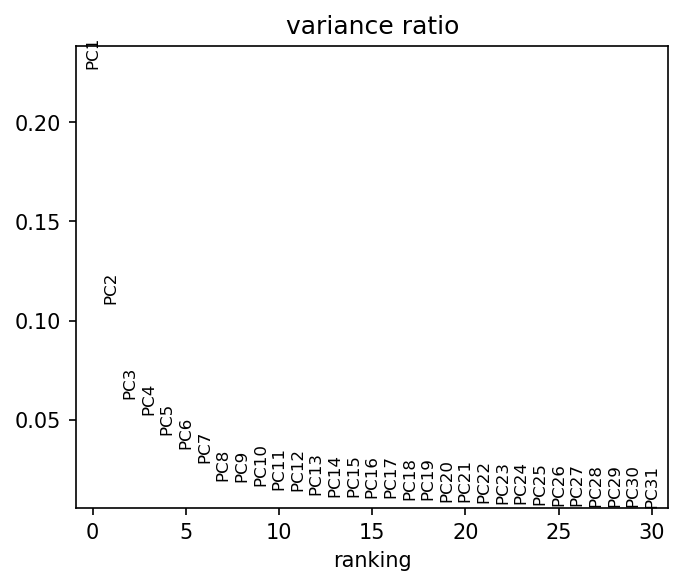

[2025-06-12 12:40:50.953] [CUML] [debug] n_neighbors=8
[2025-06-12 12:40:50.953] [CUML] [debug] Calling knn graph run
[2025-06-12 12:40:50.953] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-06-12 12:40:50.974] [CUML] [debug] Done. Calling remove zeros


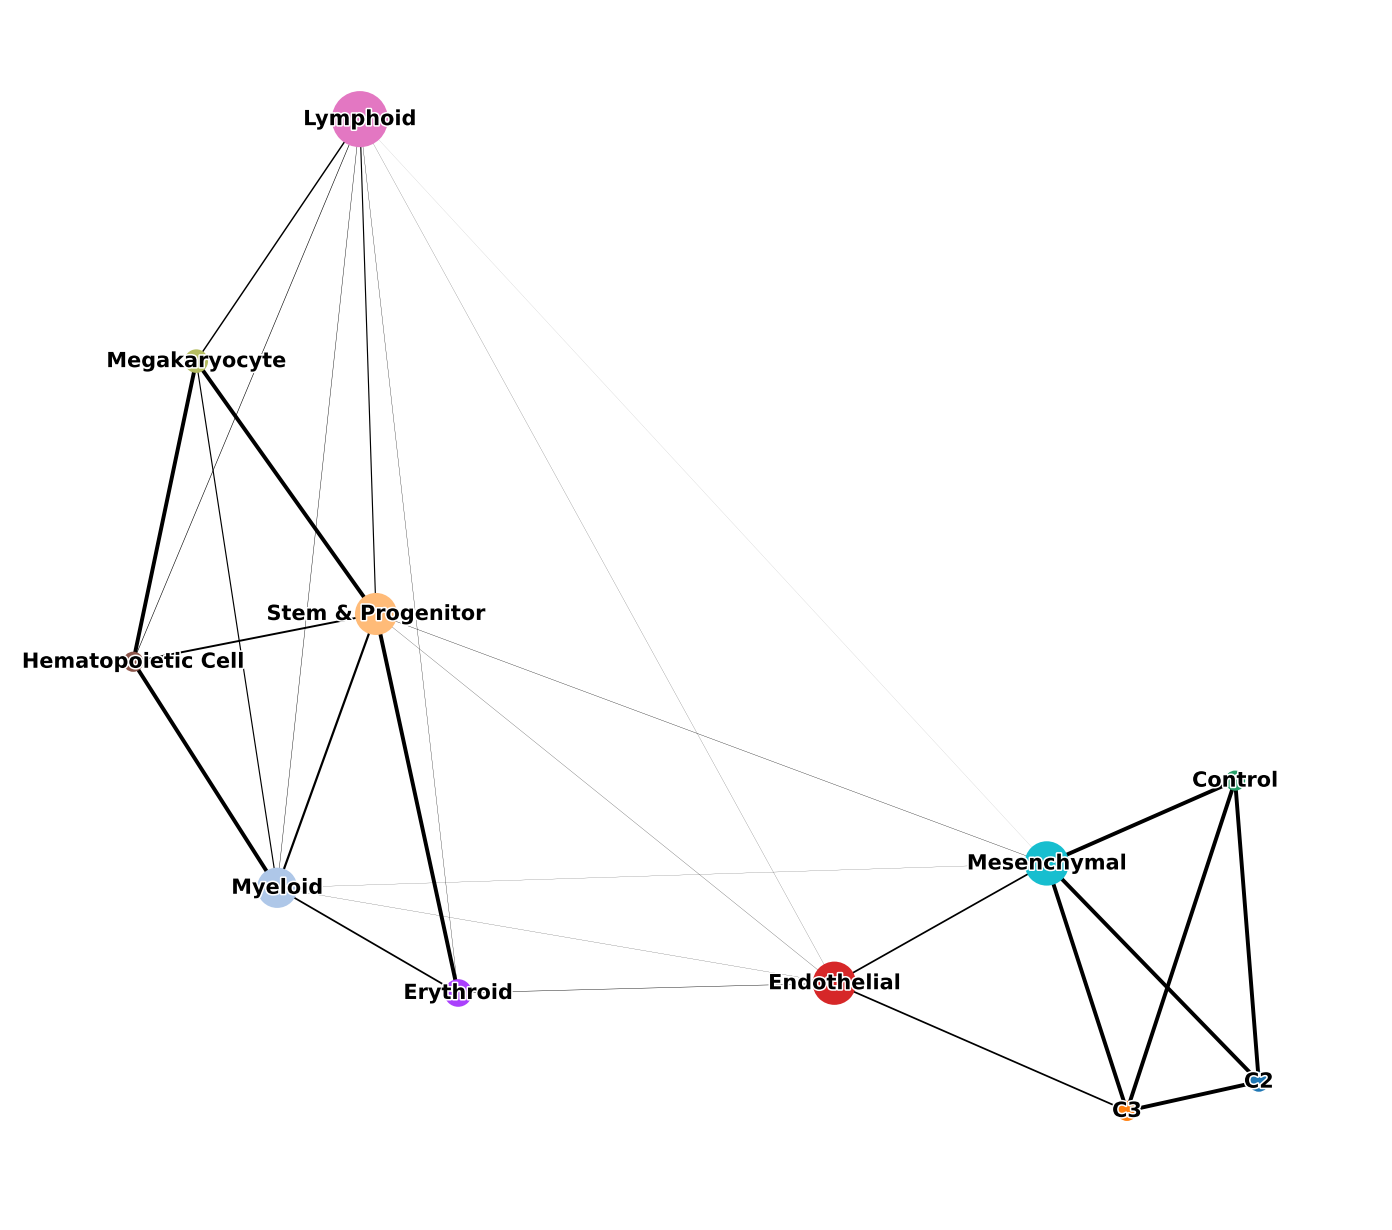

CPU times: user 8.48 s, sys: 6.3 s, total: 14.8 s
Wall time: 14.8 s


AnnData object with n_obs × n_vars = 191 × 16390
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4'
    var: 'n_counts', 'n_cells', 'filter_pass'
    uns: 'pca', 'neighbors', 'paga', 'level2_sizes', 'level2_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'sum', 'log_norm', 'probs'
    obsp: 'distances', 'connectivities'

In [14]:
%%time
rsc.get.anndata_to_GPU(adata)
rsc.pp.pca(adata, mask_var='filter_pass')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 5, 4
sc.pl.pca_variance_ratio(adata)

level = 'level2'

rsc.pp.neighbors(adata, n_neighbors=8)
sc.tl.paga(
    adata,
    groups=level,
)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 10, 10

sc.pl.paga(
    adata, 
    fontoutline=1.5, 
    edge_width_scale=0.25,  
    frameon=False,          
)

adata

In [15]:
adata.uns['paga']

{'connectivities': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 56 stored elements and shape (11, 11)>,
 'connectivities_tree': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 10 stored elements and shape (11, 11)>,
 'groups': 'level2',
 'pos': array([[ 3.31136619, -1.26638189],
        [ 2.60233036, -1.32909915],
        [ 3.18400827, -0.62022903],
        [ 1.02944425, -1.05509466],
        [-0.99345846, -1.07603943],
        [-2.74055337, -0.36503869],
        [-1.52175283,  0.79979063],
        [-2.40137583,  0.28033031],
        [ 2.171272  , -0.79796812],
        [-1.96639359, -0.85020956],
        [-1.43505637, -0.26243641]])}

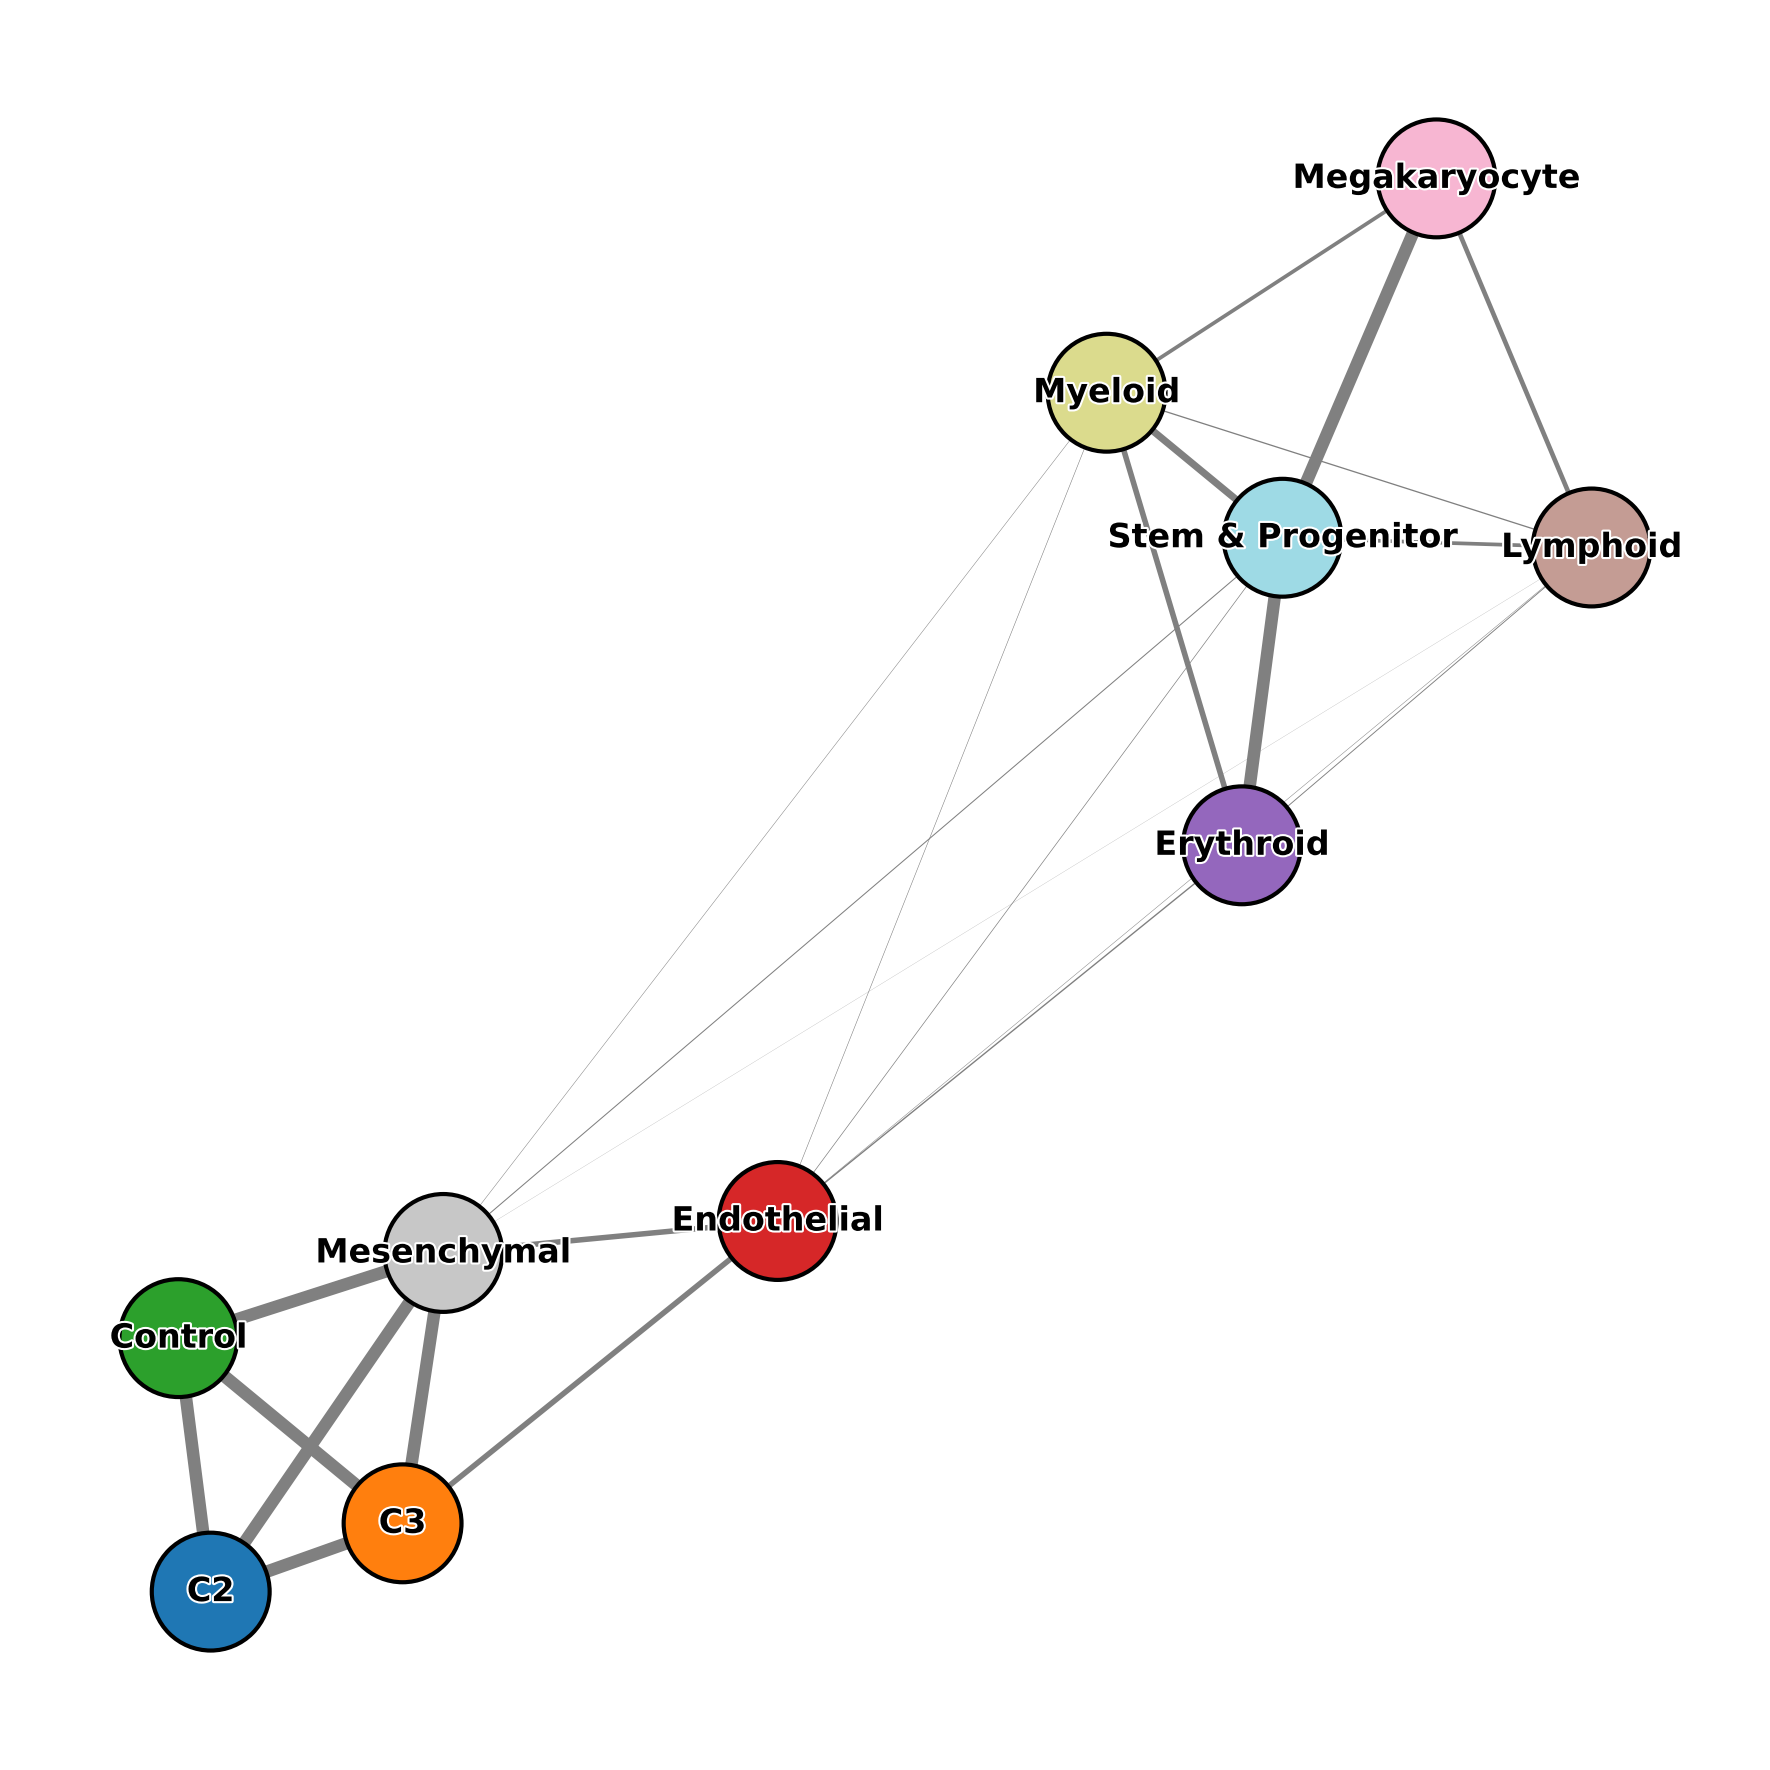

In [16]:
def paga_to_networkx(adata):
    """
    Build a NetworkX graph from adata.uns['paga'].
    
        
    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph (nodes = clusters, edges = PAGA connectivity).
    """
    # Get PAGA connectivity and cluster names
    conn = adata.uns['paga']['connectivities']
    group_key = adata.uns['paga']['groups']
    clusters = adata.obs[group_key].cat.categories

    matrix = pd.DataFrame(
        adata.uns['paga']['connectivities'].todense().copy(),
        index=clusters.values,
        columns=clusters.values,
    )

    G = nx.from_pandas_adjacency(matrix)
    G.pos = adata.uns['paga']['pos'].copy()
    return G

G = paga_to_networkx(adata)
G.remove_node('Hematopoietic Cell')

# Node colors: one color per node
node_colors = plt.cm.tab20(np.linspace(0, 1, len(G.nodes)))

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 6

# Plot
pos = nx.spring_layout(G, seed=0)
edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())

nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='grey', width=3*np.array(weights))
nx.draw_networkx_nodes(
    G, pos, 
    node_color=node_colors, 
    node_size=800, 
    edgecolors='black',   # node outline
    linewidths=1
)

# Draw labels with white border (stroke)
label_dict = {n: n for n in G.nodes}
labels = nx.draw_networkx_labels(
    G, pos, labels=label_dict, font_size=8, font_weight='bold',
)

for _, t in labels.items():
    t.set_path_effects([
        pe.Stroke(linewidth=1, foreground='white'),
        pe.Normal()
    ])

plt.axis('off')
plt.tight_layout()
plt.show()

# Distances

In [17]:
%%time
# X = adata[:, adata.var['filter_pass']].X
X = adata.obsm['X_pca'][:, 0:7]
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists, 
    index=pd.MultiIndex.from_frame(adata.obs),
    columns=pd.MultiIndex.from_frame(adata.obs),
)

df.head()

X.shape=(191, 7)
dists.shape=(191, 191)
CPU times: user 4.2 ms, sys: 1.18 ms, total: 5.38 ms
Wall time: 5.72 ms


,,,,,cell_type,C2,C3,Control,B-1 B cell,B-1a B cell,B-1b B cell,B-2 B cell,CD1c-positive myeloid dendritic cell,CD4-positive helper T cell,"CD4-positive, CD25-positive, alpha-beta regulatory T cell",...,skeletal muscle fibroblast,skin fibroblast,small pre-B-II cell,smooth muscle cell of the pulmonary artery,thymocyte,tonsil germinal center B cell,transitional stage B cell,unswitched memory B cell,vascular associated smooth muscle cell,vein endothelial cell
,,,,,group,data,data,data,atlas,atlas,atlas,atlas,atlas,atlas,atlas,...,atlas,atlas,atlas,atlas,atlas,atlas,atlas,atlas,atlas,atlas
,,,,,level1,C2,C3,Control,Hematopoietic,Hematopoietic,Hematopoietic,Hematopoietic,Hematopoietic,Hematopoietic,Hematopoietic,...,Stromal,Stromal,Hematopoietic,Stromal,Hematopoietic,Hematopoietic,Hematopoietic,Hematopoietic,Stromal,Stromal
,,,,,level2,C2,C3,Control,Lymphoid,Lymphoid,Lymphoid,Lymphoid,Myeloid,Lymphoid,Lymphoid,...,Mesenchymal,Mesenchymal,Stem & Progenitor,Mesenchymal,Lymphoid,Lymphoid,Lymphoid,Lymphoid,Mesenchymal,Endothelial
,,,,,level3,C2,C3,Control,B Cell,B Cell,B Cell,B Cell,Dendritic Cell,T Cell,T Cell,...,Fibroblast,Fibroblast,B Cell Progenitor,Smooth Muscle Cell,T Cell Progenitor,B Cell,B Cell,B Cell,Smooth Muscle Cell,Endothelial Cell
,,,,,level4,C2,C3,Control,B-1 B Cell,B-1 B Cell,B-1 B Cell,Mature B Cell,Conventional Dendritic Cell,"CD4-positive, alpha-beta T cell",Regulatory T cell,...,Fibroblast,Fibroblast,B Cell Progenitor,Smooth Muscle Cell,Thymocyte,Germinal Center B Cell,Mature B Cell,Memory B Cell,Smooth Muscle Cell,Venous Endothelial Cell
cell_type,group,level1,level2,level3,level4,,,,,,,,,,,,,,,,,,,,,
C2,data,C2,C2,C2,C2,0.000000,11.292431,5.108847,28.606821,30.988245,32.666977,29.657444,30.224110,29.707636,27.829254,...,43.301949,17.749380,33.410957,18.840496,23.482779,31.421011,29.779190,36.653481,15.845671,26.382517
C3,data,C3,C3,C3,C3,11.292431,0.000000,11.039809,32.378773,33.929340,34.909386,33.154167,30.742815,31.095795,31.227926,...,32.999306,21.017111,35.380795,13.680801,28.760355,34.233902,32.932713,36.354687,18.713751,28.632320
Control,data,Control,Control,Control,Control,5.108847,11.039809,0.000000,30.002203,31.839243,33.539154,31.143078,32.262184,30.756577,29.470507,...,42.012817,15.475324,33.728493,15.481585,24.978706,32.090496,32.010075,37.670300,12.029425,26.441696
B-1 B cell,atlas,Hematopoietic,Lymphoid,B Cell,B-1 B Cell,28.606821,32.378773,30.002203,0.000000,5.740302,6.335652,3.218144,25.939270,21.546808,16.814587,...,55.249283,35.725262,9.130572,37.141083,16.366505,8.771909,10.503211,16.665020,33.791836,34.463127


df_agg.shape=(10, 10)


/tmp/ipykernel_2142081/2304902318.py:3: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
/tmp/ipykernel_2142081/2304902318.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
/tmp/ipykernel_2142081/2304902318.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn

Text(1971.440476190476, 0.5, '')

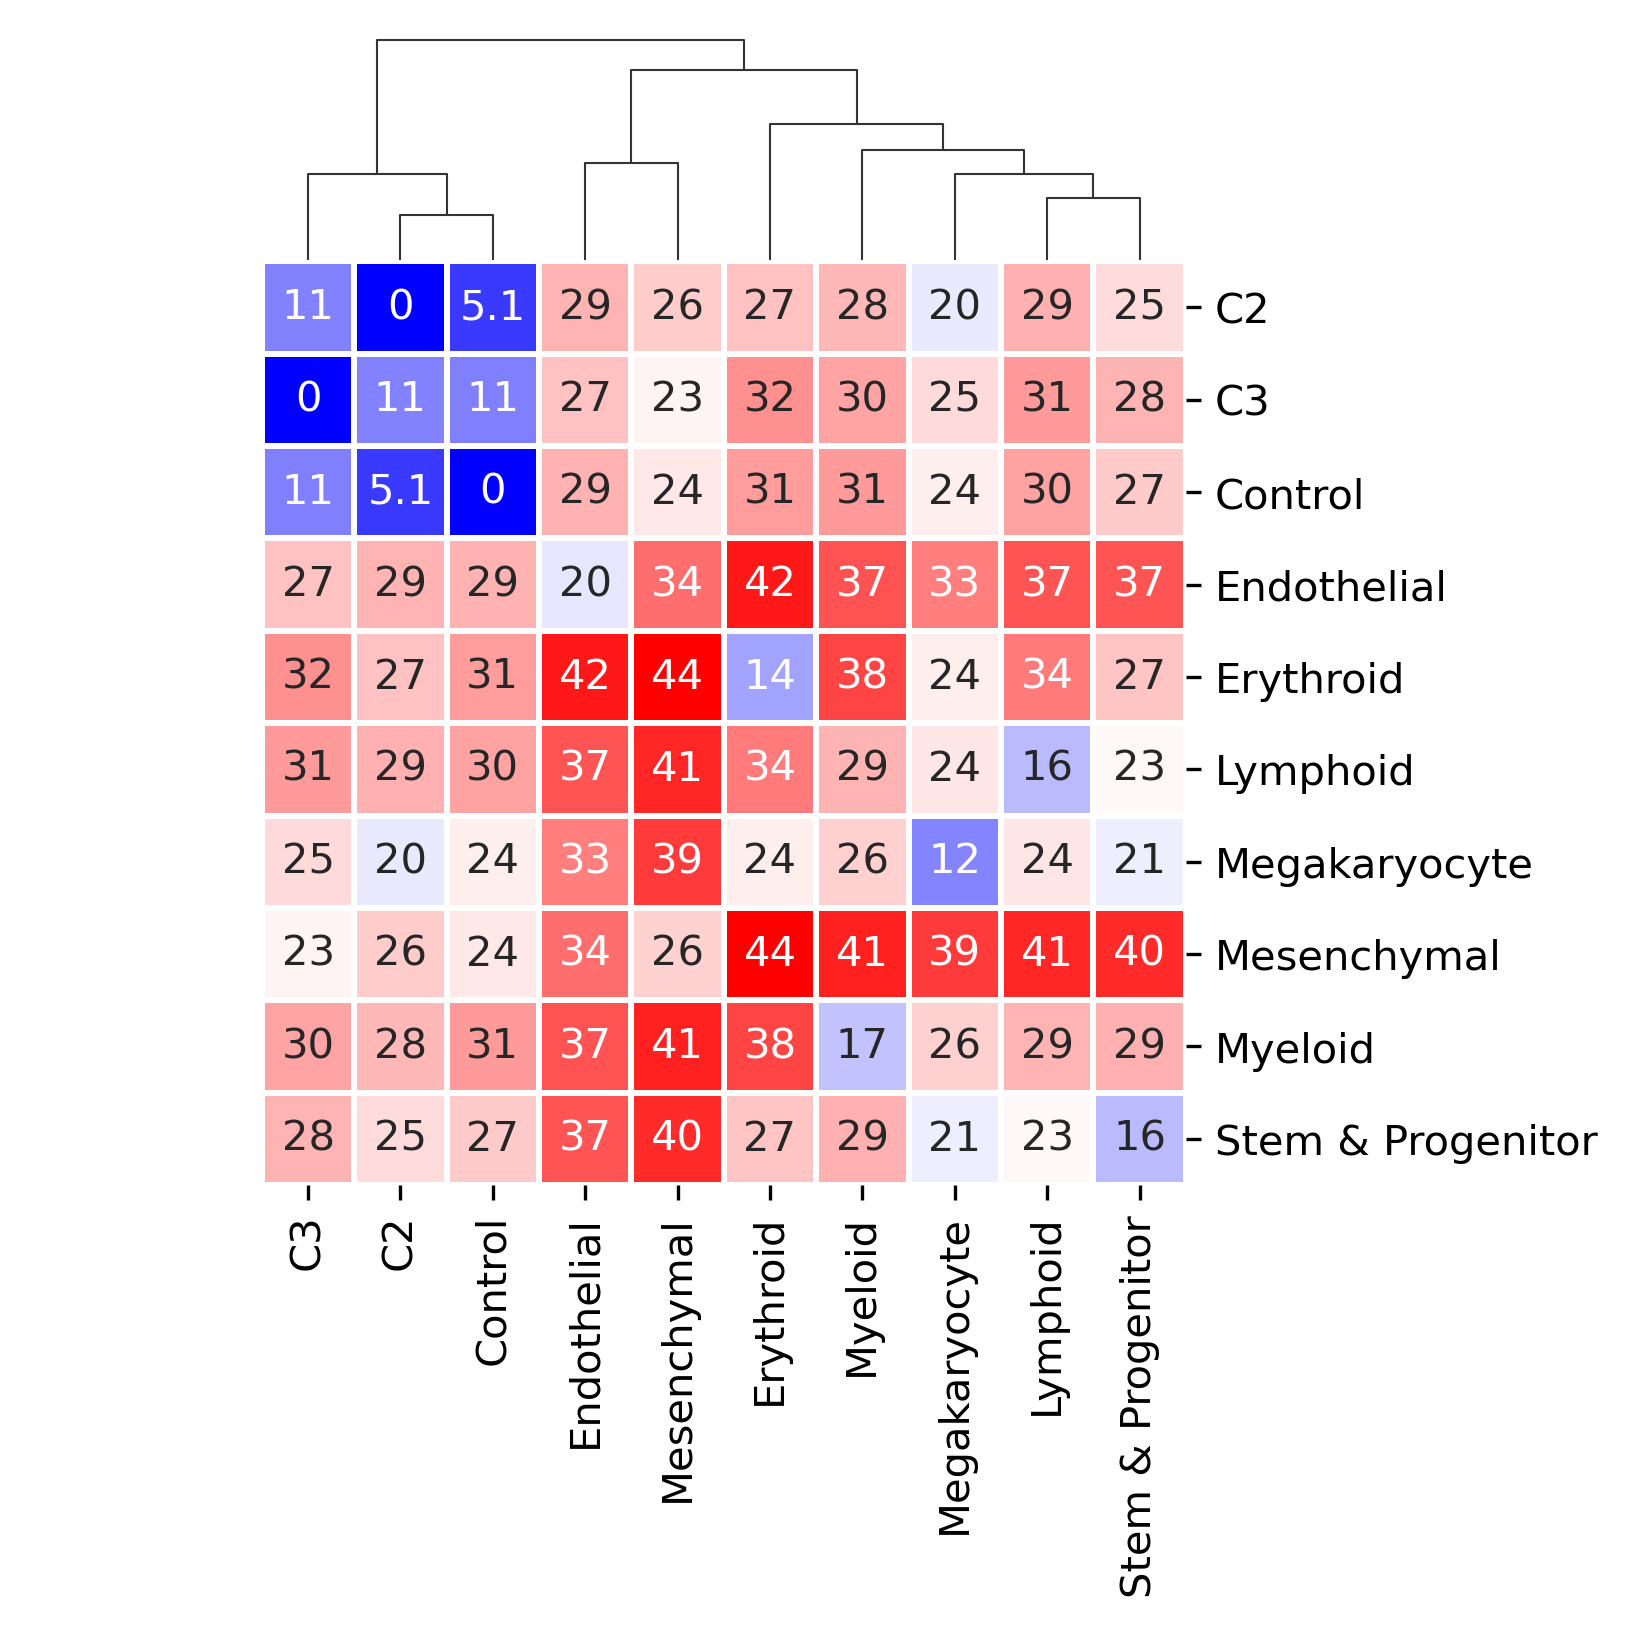

In [18]:
# Aggregate by 'cell_type' for both axes
level = "level2"
df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
df_agg = df_agg.sort_index()

drop = 'Hematopoietic Cell'
df_agg = df_agg.sort_index().drop(drop).drop(drop, axis=1)
print(f"{df_agg.shape=}")
n = df_agg.shape[0]

g = sns.clustermap(
    df_agg,
    square=True,
    cmap='bwr',
    linewidth=1,
    figsize=( n / 1.75 ,n / 1.75),
    annot=True,
    cbar_pos=None,
    row_cluster=False,
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

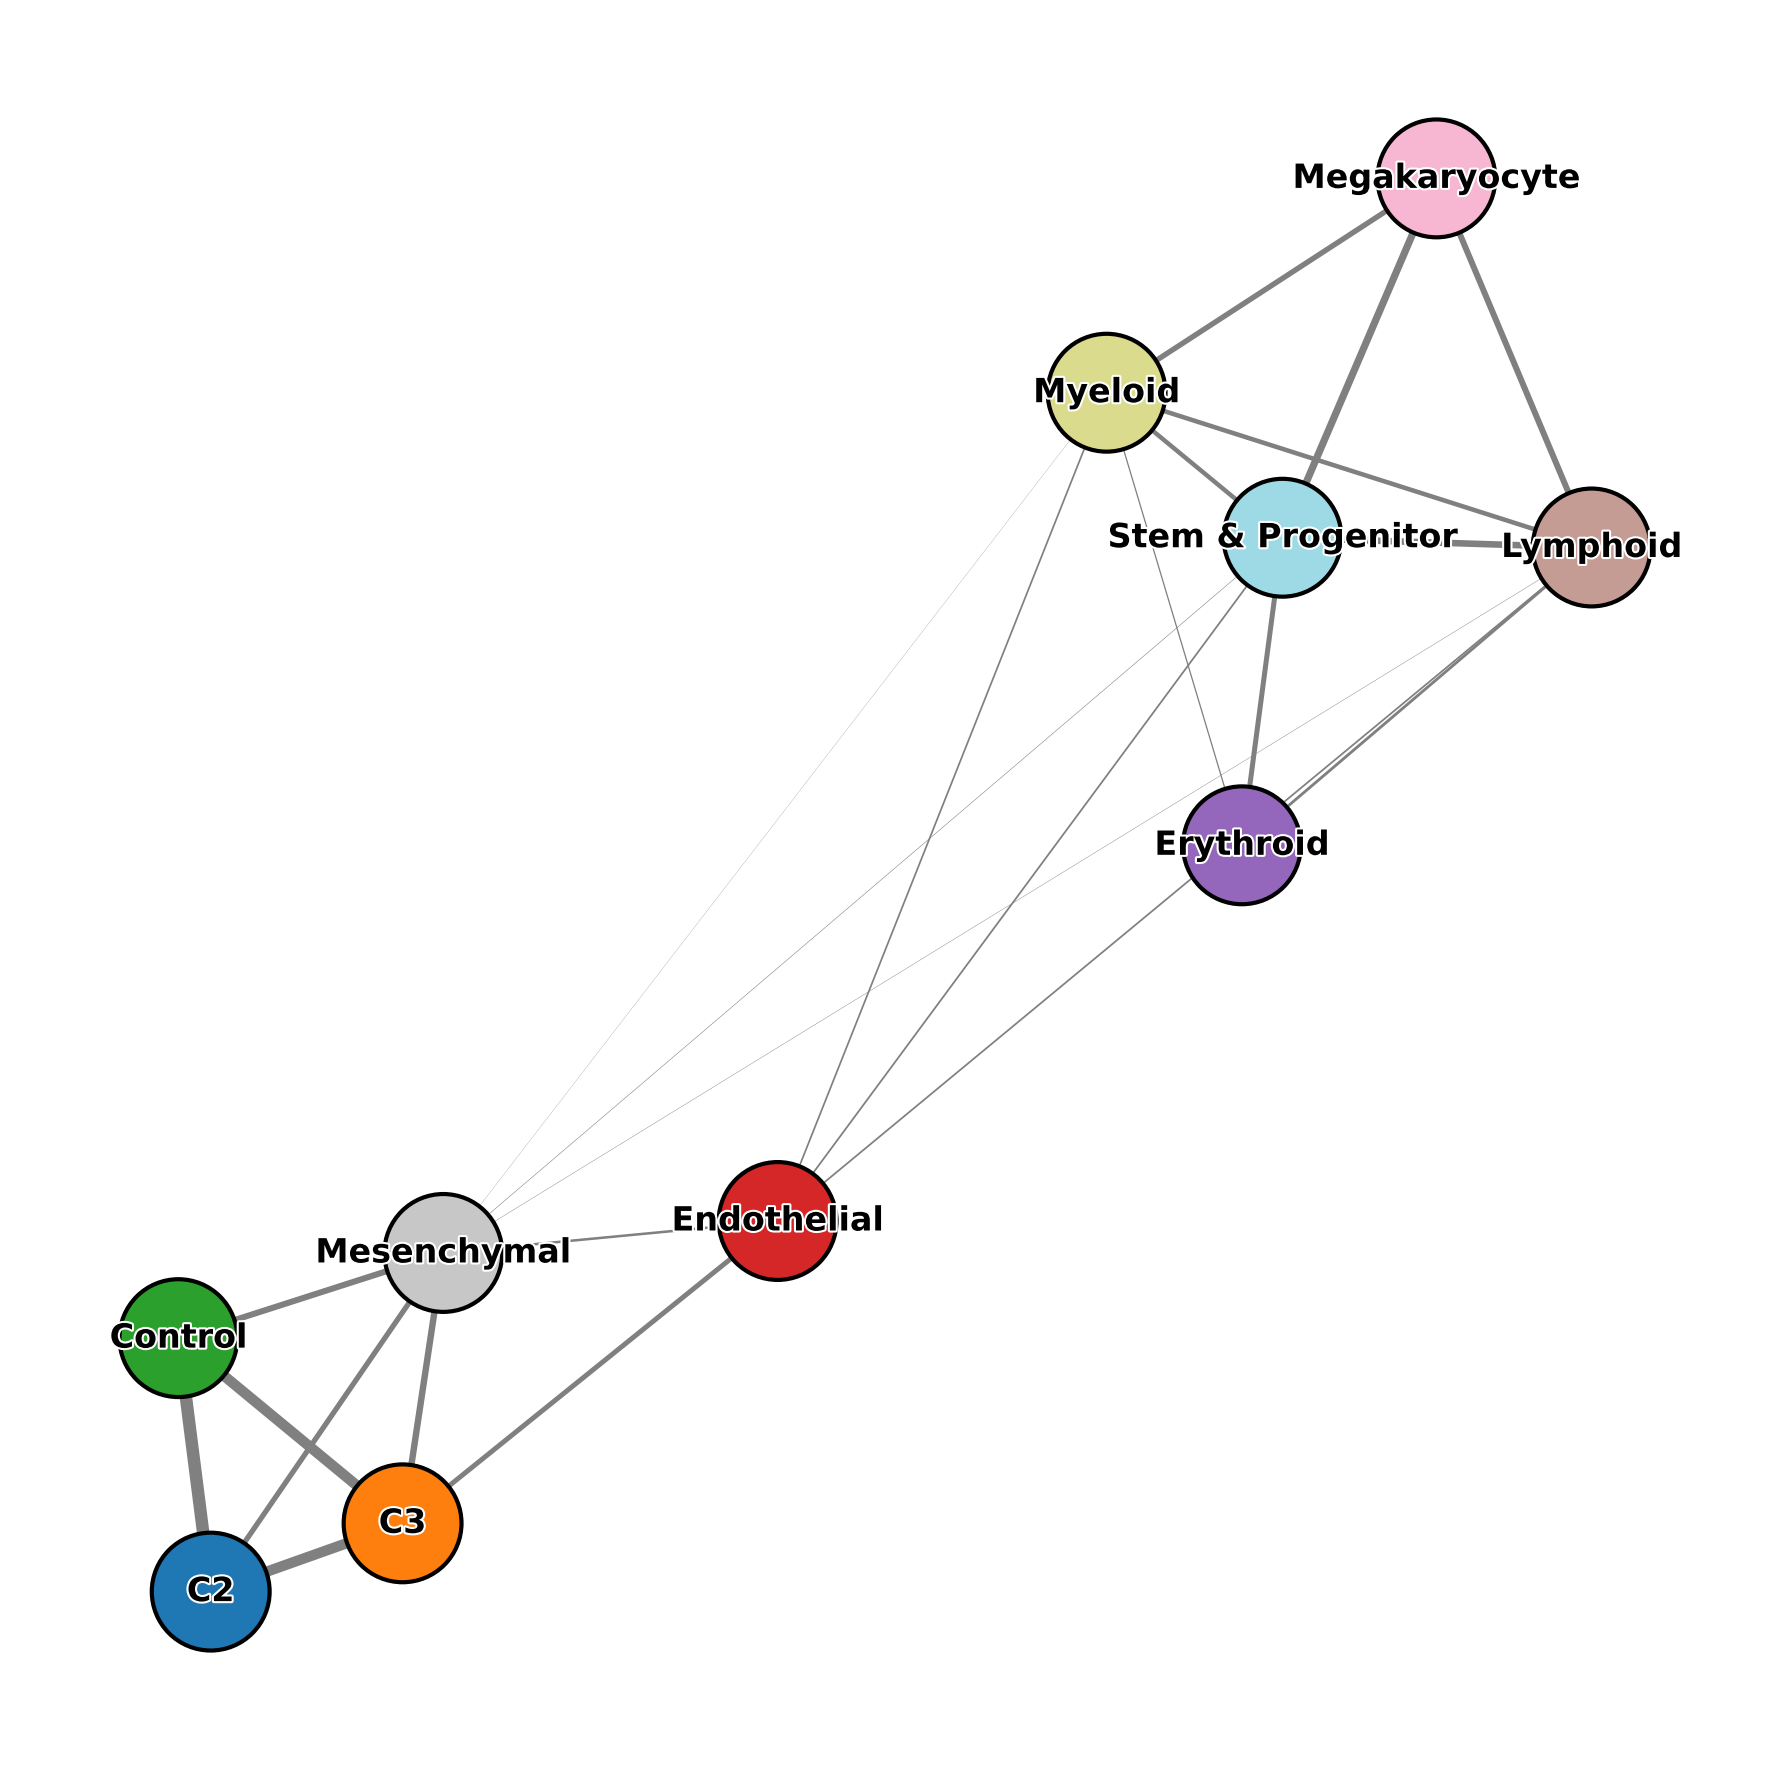

In [19]:
G = paga_to_networkx(adata)
G.remove_node('Hematopoietic Cell')

# Node colors: one color per node
node_colors = plt.cm.tab20(np.linspace(0, 1, len(G.nodes)))

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 6

# Plot
pos = nx.spring_layout(G, seed=0)
edges, _ = zip(*nx.get_edge_attributes(G, 'weight').items())

weights = np.array([df_agg.loc[a, b] for a, b in edges])
weights = (weights - weights.min()) / (weights.max() - weights.min())
weights = 1 - weights

nx.draw_networkx_edges(
    G, 
    pos, 
    width=3*weights, 
    edge_color='grey',
)

nx.draw_networkx_nodes(
    G, pos, 
    node_color=node_colors, 
    node_size=800, 
    edgecolors='black',   # node outline
    linewidths=1
)

# Draw labels with white border (stroke)
label_dict = {n: n for n in G.nodes}
labels = nx.draw_networkx_labels(
    G, pos, labels=label_dict, font_size=8, font_weight='bold',
)

for _, t in labels.items():
    t.set_path_effects([
        pe.Stroke(linewidth=1, foreground='white'),
        pe.Normal()
    ])

plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2142081/473616006.py:3: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
/tmp/ipykernel_2142081/473616006.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
/tmp/ipykernel_2142081/473616006.py:3: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(ms

['B Cell', 'B Cell Progenitor', 'C2', 'C3', 'Control', 'Dendritic Cell', 'Endothelial Cell', 'Erythrocyte', 'Erythroid Progenitor', 'Fibroblast', 'Granulocyte', 'Hematopoietic Cell', 'Hematopoietic Progenitor', 'Hematopoietic Stem Cell', 'Innate Lymphoid Cell', 'Lymphocyte', 'Lymphoid Progenitor', 'Macrophage', 'Mast Cell', 'Megakaryocyte', 'Megakaryocyte Progenitor', 'Mesenchymal Stem Cell', 'Mesothelial Cell', 'Monocyte', 'Multipotent Progenitor', 'Myeloid', 'Myeloid Progenitor', 'Myofibroblast', 'Pericyte', 'Platelet', 'Smooth Muscle Cell', 'T Cell', 'T Cell Progenitor']
df_agg.shape=(33, 33)


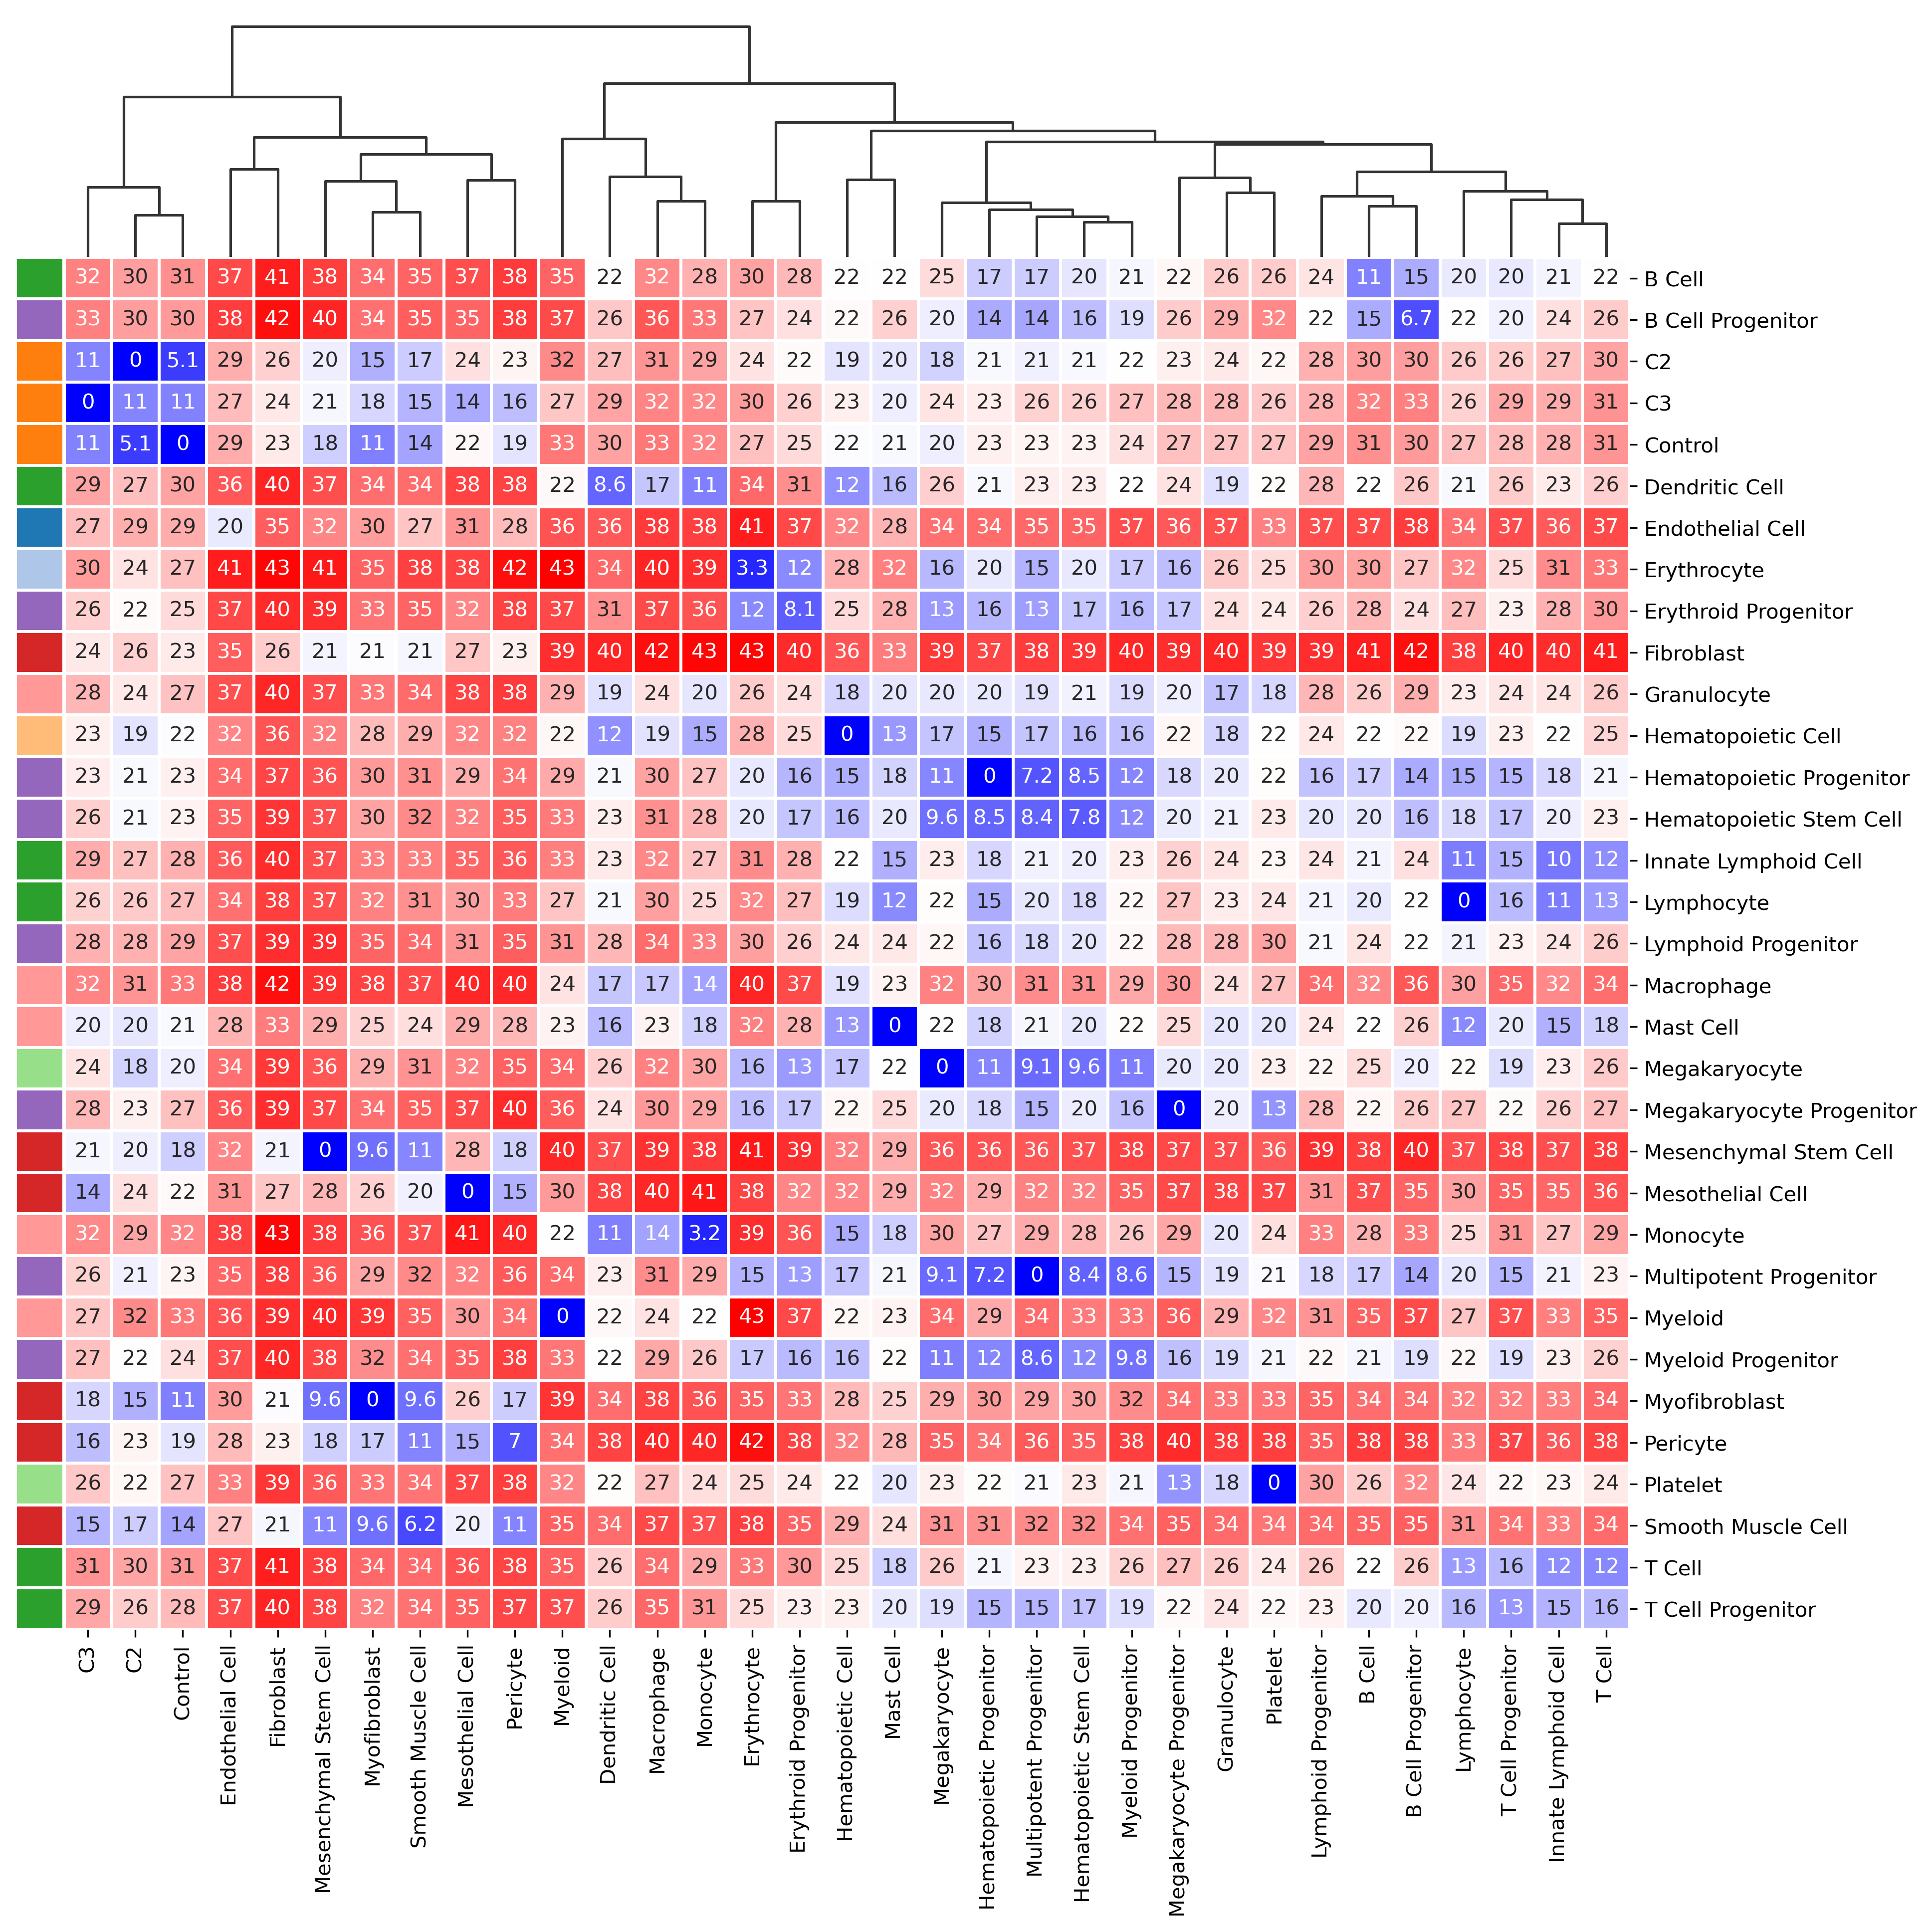

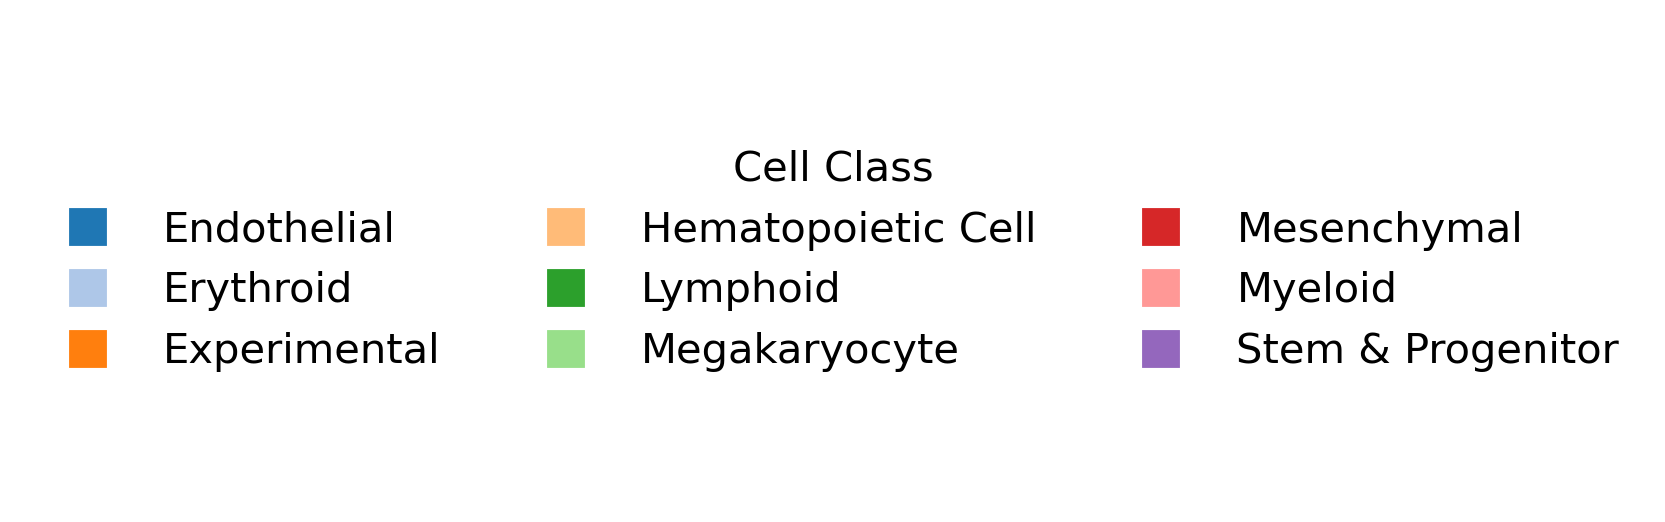

In [20]:
# Aggregate by 'cell_type' for both axes
level = "level3"
df_agg = df.groupby(level=level, axis=0).mean().groupby(level=level, axis=1).mean()
df_agg = df_agg.sort_index()

drop = ['Adipocyte', 'Mesenchymal Progenitor', 'Stellate Cell', 'Reticulocyte']
df_agg = df_agg.sort_index().drop(drop).drop(drop, axis=1)
print(list(df_agg.index))
print(f"{df_agg.shape=}")
n = df_agg.shape[0]


mapping = {
    k: v
    for k, v in zip(
        df.index.get_level_values('level3'),
        df.index.get_level_values('level2')
    )
}

row_colors = df_agg.index.map(mapping)
row_colors = ['Experimental' if v in ['C2', 'C3', 'Control'] else v for v in row_colors]
unique_vals = list(np.unique(row_colors))
color_list = sns.color_palette('tab20', n_colors=len(unique_vals)).as_hex()

# Create mapping
color_dict = dict(zip(unique_vals, color_list))

# Map each value in row_colors to its color
mapped_colors = [color_dict[v] for v in row_colors]

g = sns.clustermap(
    df_agg,
    square=True,
    # cmap='vlag',
    cmap='bwr',
    row_colors=mapped_colors,
    linewidth=1,
    figsize=( n / 2.5 ,n / 2.5),
    dendrogram_ratio=(0.0, 0.15),
    annot=True,
    cbar_pos=None,
    row_cluster=False,
    tree_kws={'lw' : 1.25,}
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")
plt.show()

# Standalone legend
handles = [
    plt.Line2D([0], [0], marker='s', color='w', label=key,
               markerfacecolor=color, markersize=10)
    for key, color in color_dict.items()
]

plt.figure(figsize=(2, 2))
plt.legend(handles=handles, title="Cell Class", loc='center', ncol=3, frameon=False,)
plt.axis('off')
plt.show()

# Multidimensional Scaling

X.shape=(191, 15814)
dists.shape=(191, 191)
CPU times: user 941 ms, sys: 21.1 ms, total: 962 ms
Wall time: 970 ms


,MDS1,MDS2,cell_type,group,level1,level2,level3,level4
0,15.346406,-28.016478,C2,data,C2,C2,C2,C2
1,-28.134562,-3.434580,C3,data,C3,C3,C3,C3
2,12.950122,-29.726262,Control,data,Control,Control,Control,Control
3,12.202712,10.882128,B-1 B cell,atlas,Hematopoietic,Lymphoid,B Cell,B-1 B Cell
4,16.441997,19.725891,B-1a B cell,atlas,Hematopoietic,Lymphoid,B Cell,B-1 B Cell


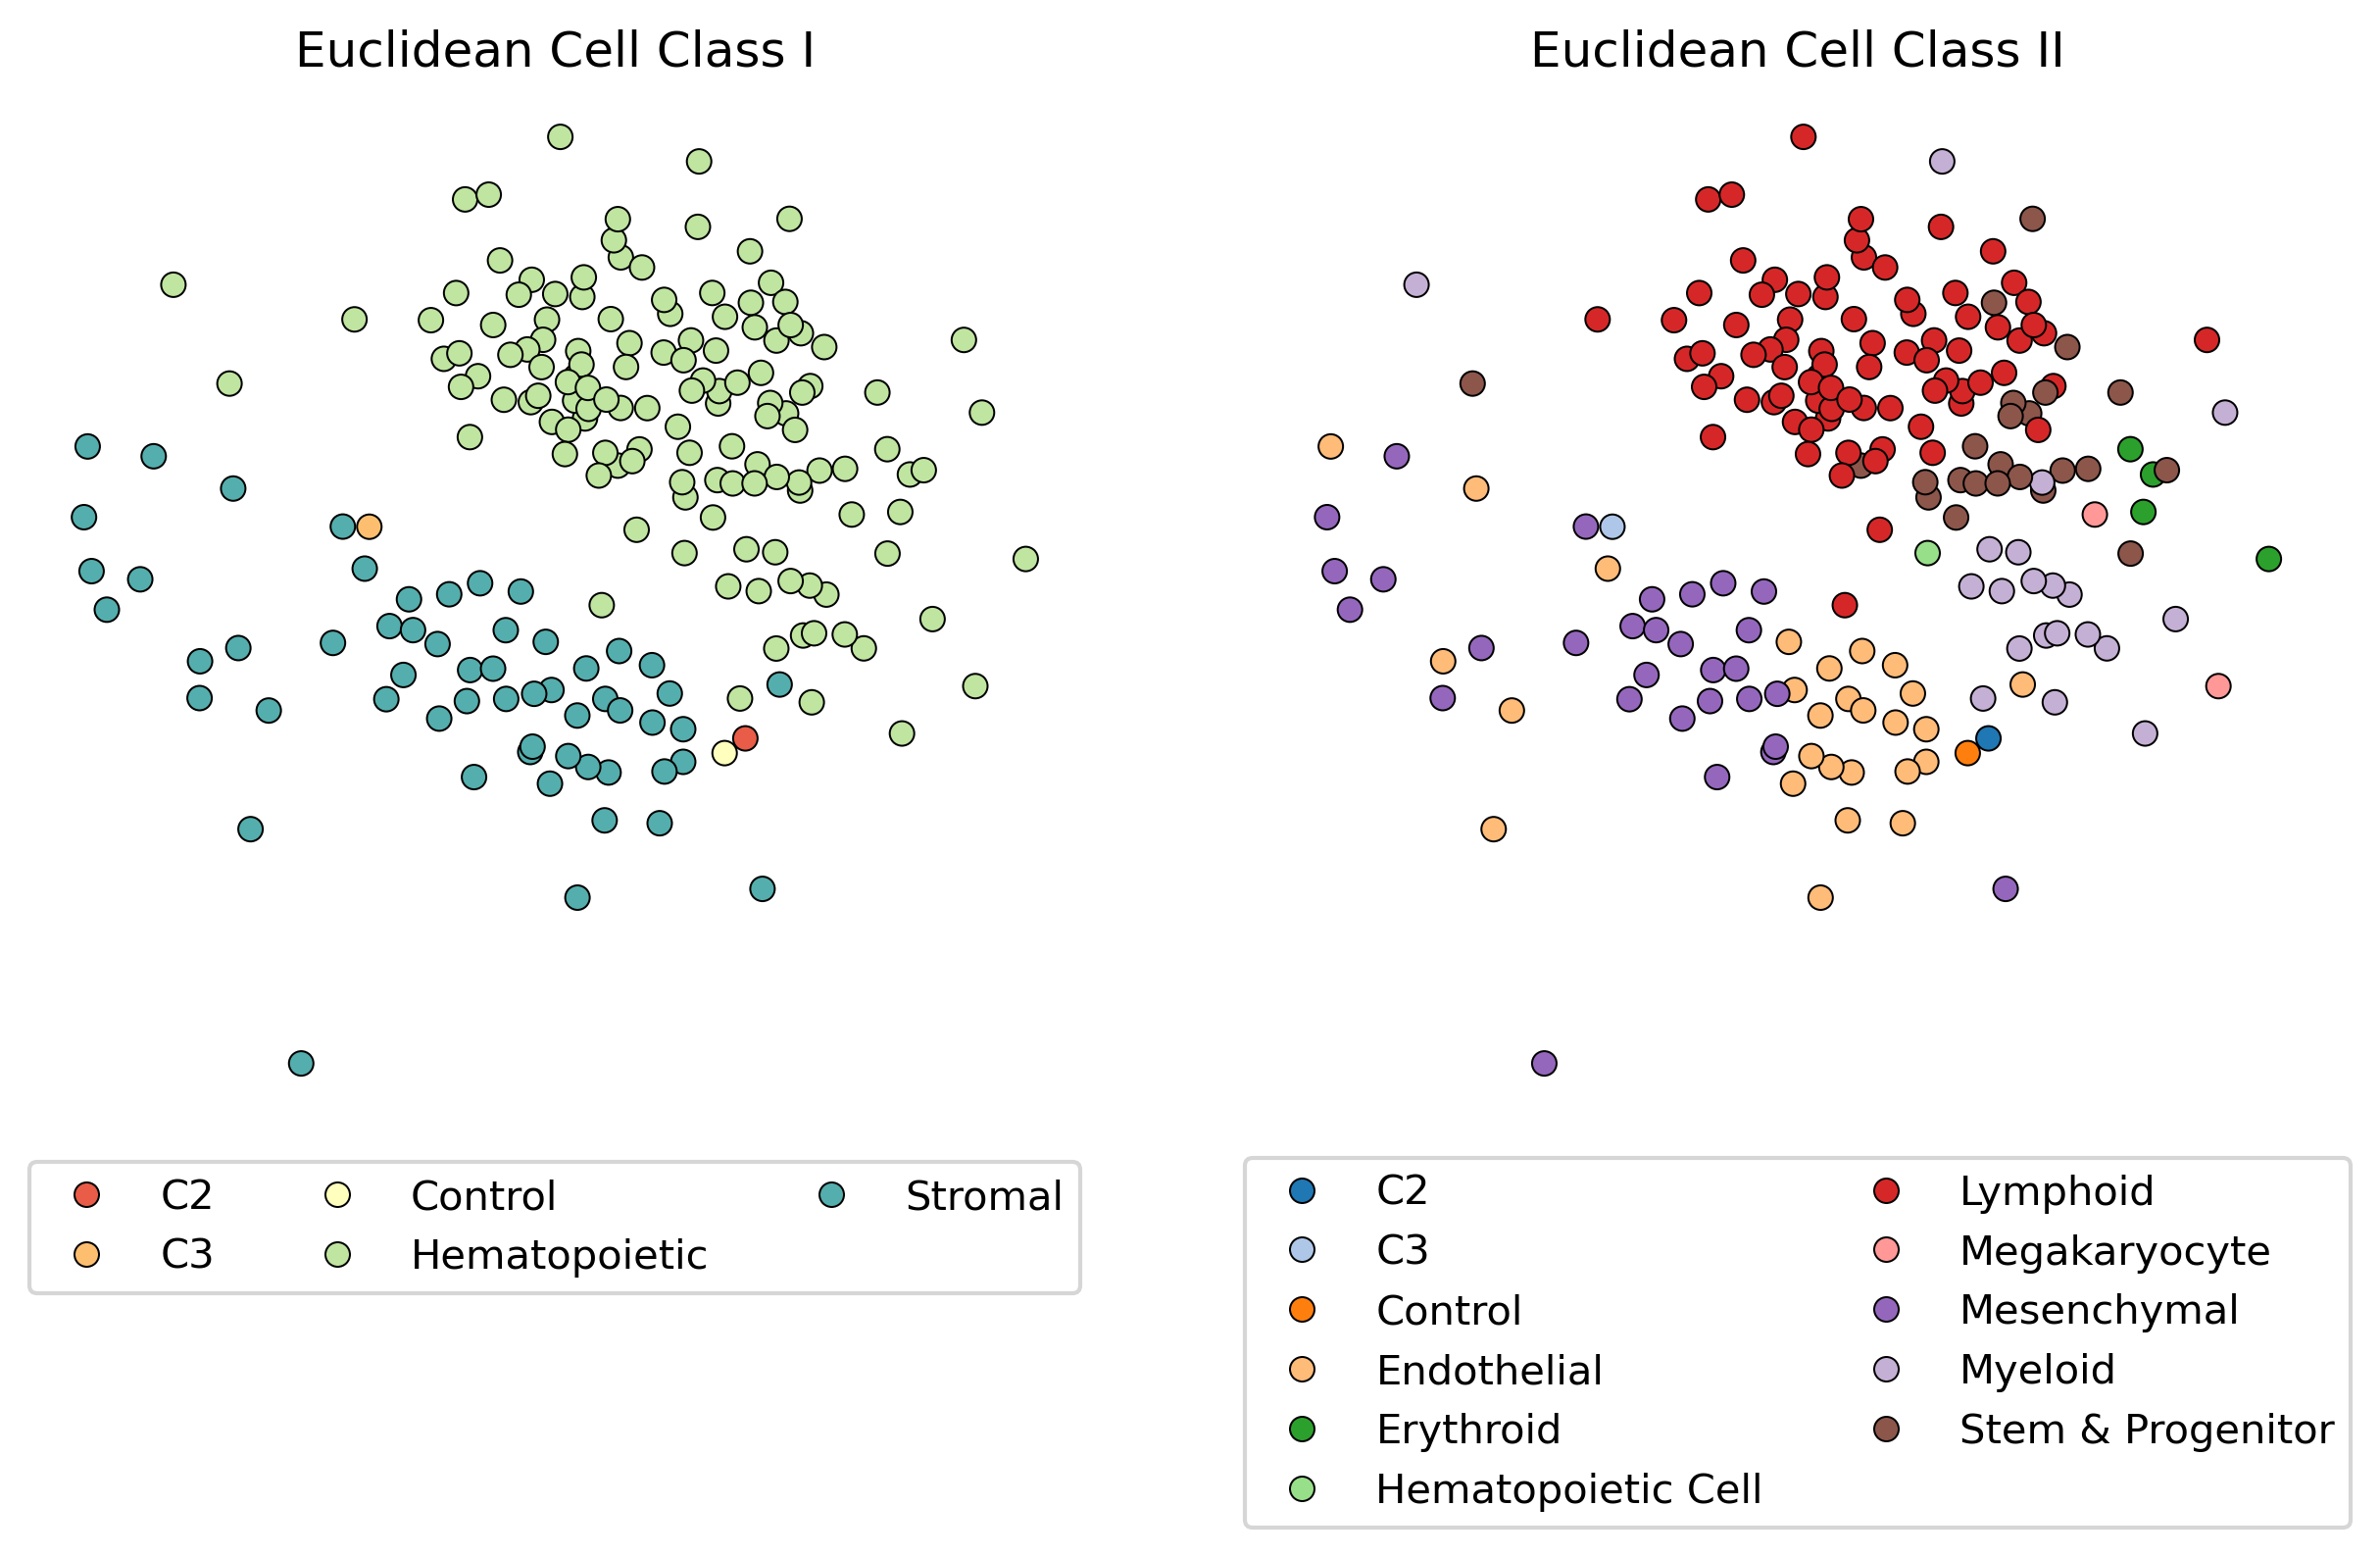

In [21]:
%%time
metric = 'euclidean'
X = adata[:, adata.var['filter_pass']].X
print(f"{X.shape=}")

dists = pairwise_distances(X, metric=metric)
print(f"{dists.shape=}")

embedding = MDS(n_components=2, random_state=1729, dissimilarity='precomputed').fit_transform(dists.get())
embedding = pd.DataFrame(embedding, columns=['MDS1', 'MDS2'])
embedding = pd.concat([embedding, adata.obs.reset_index(drop=True).copy()], axis=1)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10, 4.5

fig, axes = plt.subplots(1, 2)

sns.scatterplot(
    data=embedding,
    x='MDS1',
    y='MDS2',
    hue='level1',
    ec='k',
    palette='Spectral',
    ax=axes[0],
)

axes[0].set_title(f"{metric.title()} Cell Class I")
axes[0].axis(False)

sns.move_legend(
    axes[0],
    title="",
    loc='lower center',
    ncols=3,
    bbox_to_anchor=(0.5, -0.2),
)

sns.scatterplot(
    data=embedding,
    x='MDS1',
    y='MDS2',
    hue='level2',
    ec='k',
    palette='tab20',
    ax=axes[1],
)

axes[1].set_title(f"{metric.title()} Cell Class II")
axes[1].axis(False)

sns.move_legend(
    axes[1],
    title="",
    loc='lower center',
    ncols=2,
    bbox_to_anchor=(0.5, -0.43),
)

embedding.head()

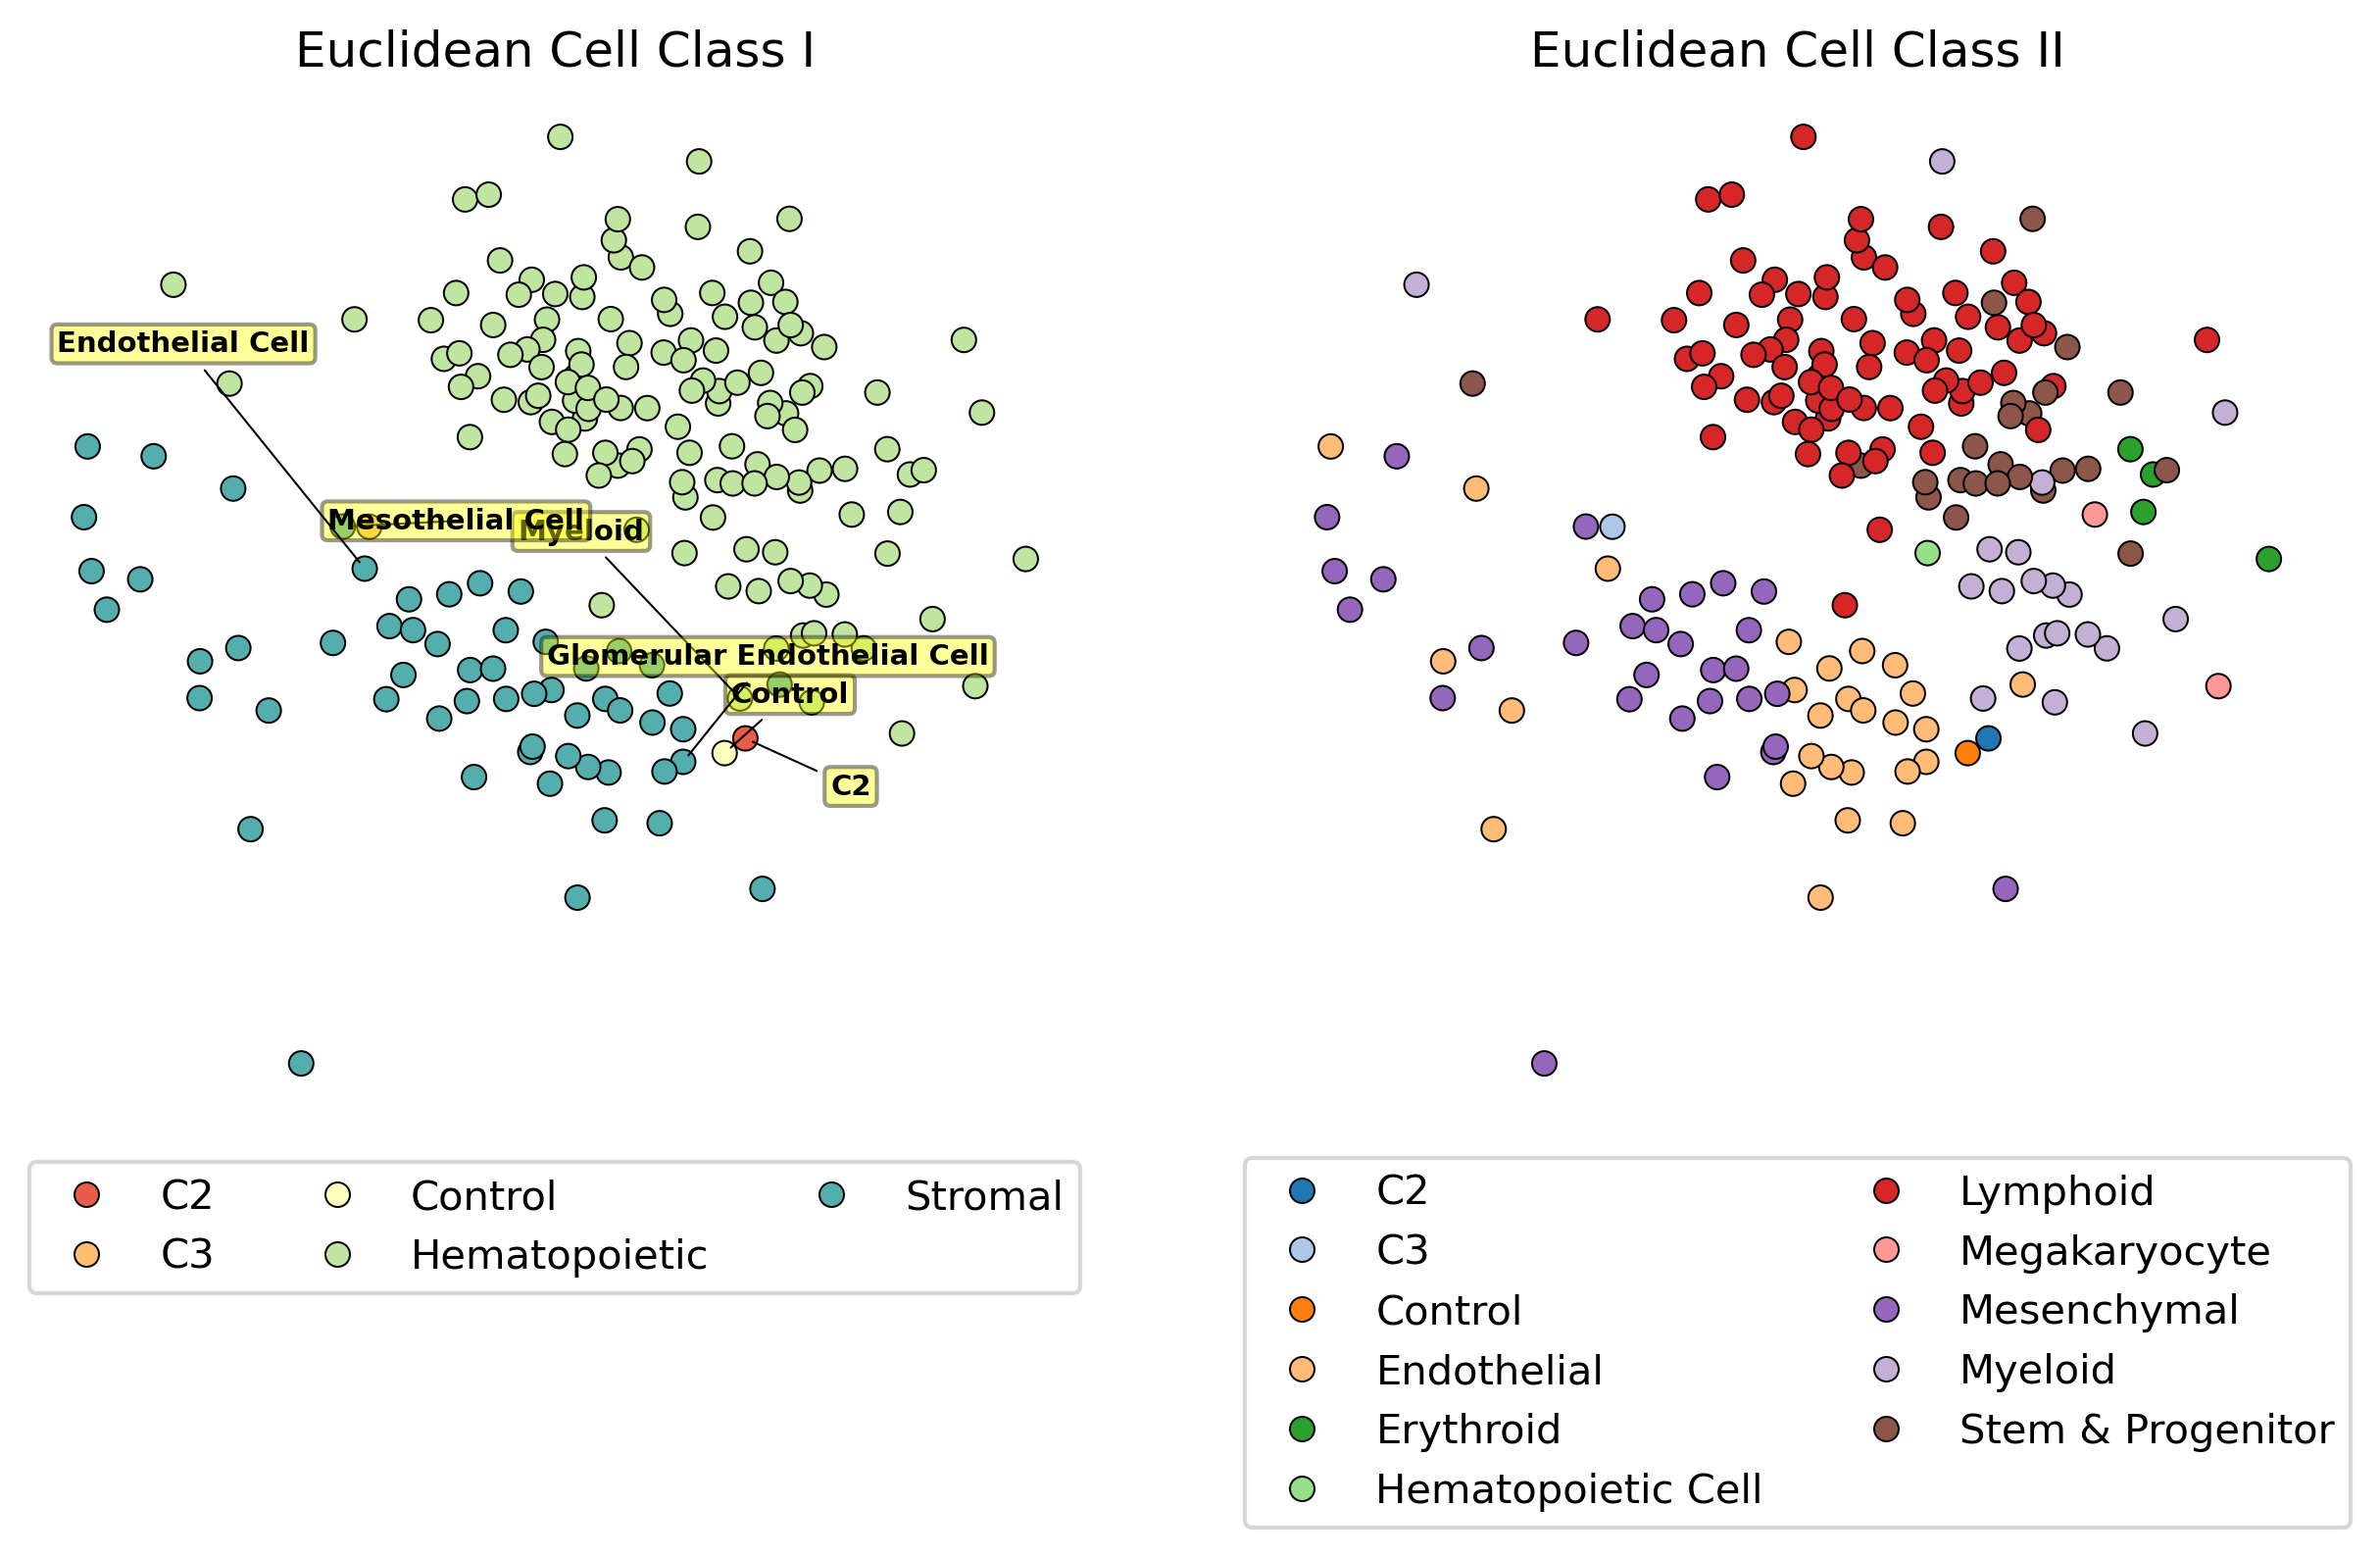

In [22]:

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 10, 4.5

fig, axes = plt.subplots(1, 2)

sns.scatterplot(
    data=embedding,
    x='MDS1',
    y='MDS2',
    hue='level1',
    ec='k',
    palette='Spectral',
    ax=axes[0],
)

axes[0].set_title(f"{metric.title()} Cell Class I")
axes[0].axis(False)

sns.move_legend(
    axes[0],
    title="",
    loc='lower center',
    ncols=3,
    bbox_to_anchor=(0.5, -0.2),
)

sns.scatterplot(
    data=embedding,
    x='MDS1',
    y='MDS2',
    hue='level2',
    ec='k',
    palette='tab20',
    ax=axes[1],
)

axes[1].set_title(f"{metric.title()} Cell Class II")
axes[1].axis(False)

sns.move_legend(
    axes[1],
    title="",
    loc='lower center',
    ncols=2,
    bbox_to_anchor=(0.5, -0.43),
)

k = 2
anchors = ['C2', 'C3', 'Control']
texts = []

for anchor in anchors:
    anchor_idx = embedding.index[embedding['level1'] == anchor][0]
    anchor_point = embedding.loc[anchor_idx, ['MDS1', 'MDS2']].to_numpy(dtype=float)
    points = embedding[['MDS1', 'MDS2']].to_numpy(dtype=float)
    dists = np.linalg.norm(points - anchor_point, axis=1)
    dists[anchor_idx] = np.inf

    closest_idxs = np.argsort(dists)[:k]

    for i in closest_idxs:
        x, y = points[i]
        label = embedding.loc[i, 'level4']
        # Queue the annotation, do NOT plot arrows yet
        texts.append(
            axes[0].annotate(
                label,
                (x, y),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=7,
                color='black',
                weight='bold',
                bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.4),
                arrowprops=dict(arrowstyle="-", color='black', lw=0.5),
                zorder=20,
            )
        )

# Automatically adjust text to minimize overlap
adjust_text(
    texts, 
    ax=axes[0],
    # expand_text=(2.5, 2.5),        # default is (1.05, 1.2), increase for more spacing
    # expand_points=(2.5, 2.5),
    # force_text=3,                # default 0.1, higher = more force
    # force_points=1.2,              # default 0.1
    # lim=200,    
)
plt.show()

# Who is closest?

X.shape=(191, 7)
dists.shape=(191, 191)
df.shape=(191, 191)
pdf.shape=(191, 191)


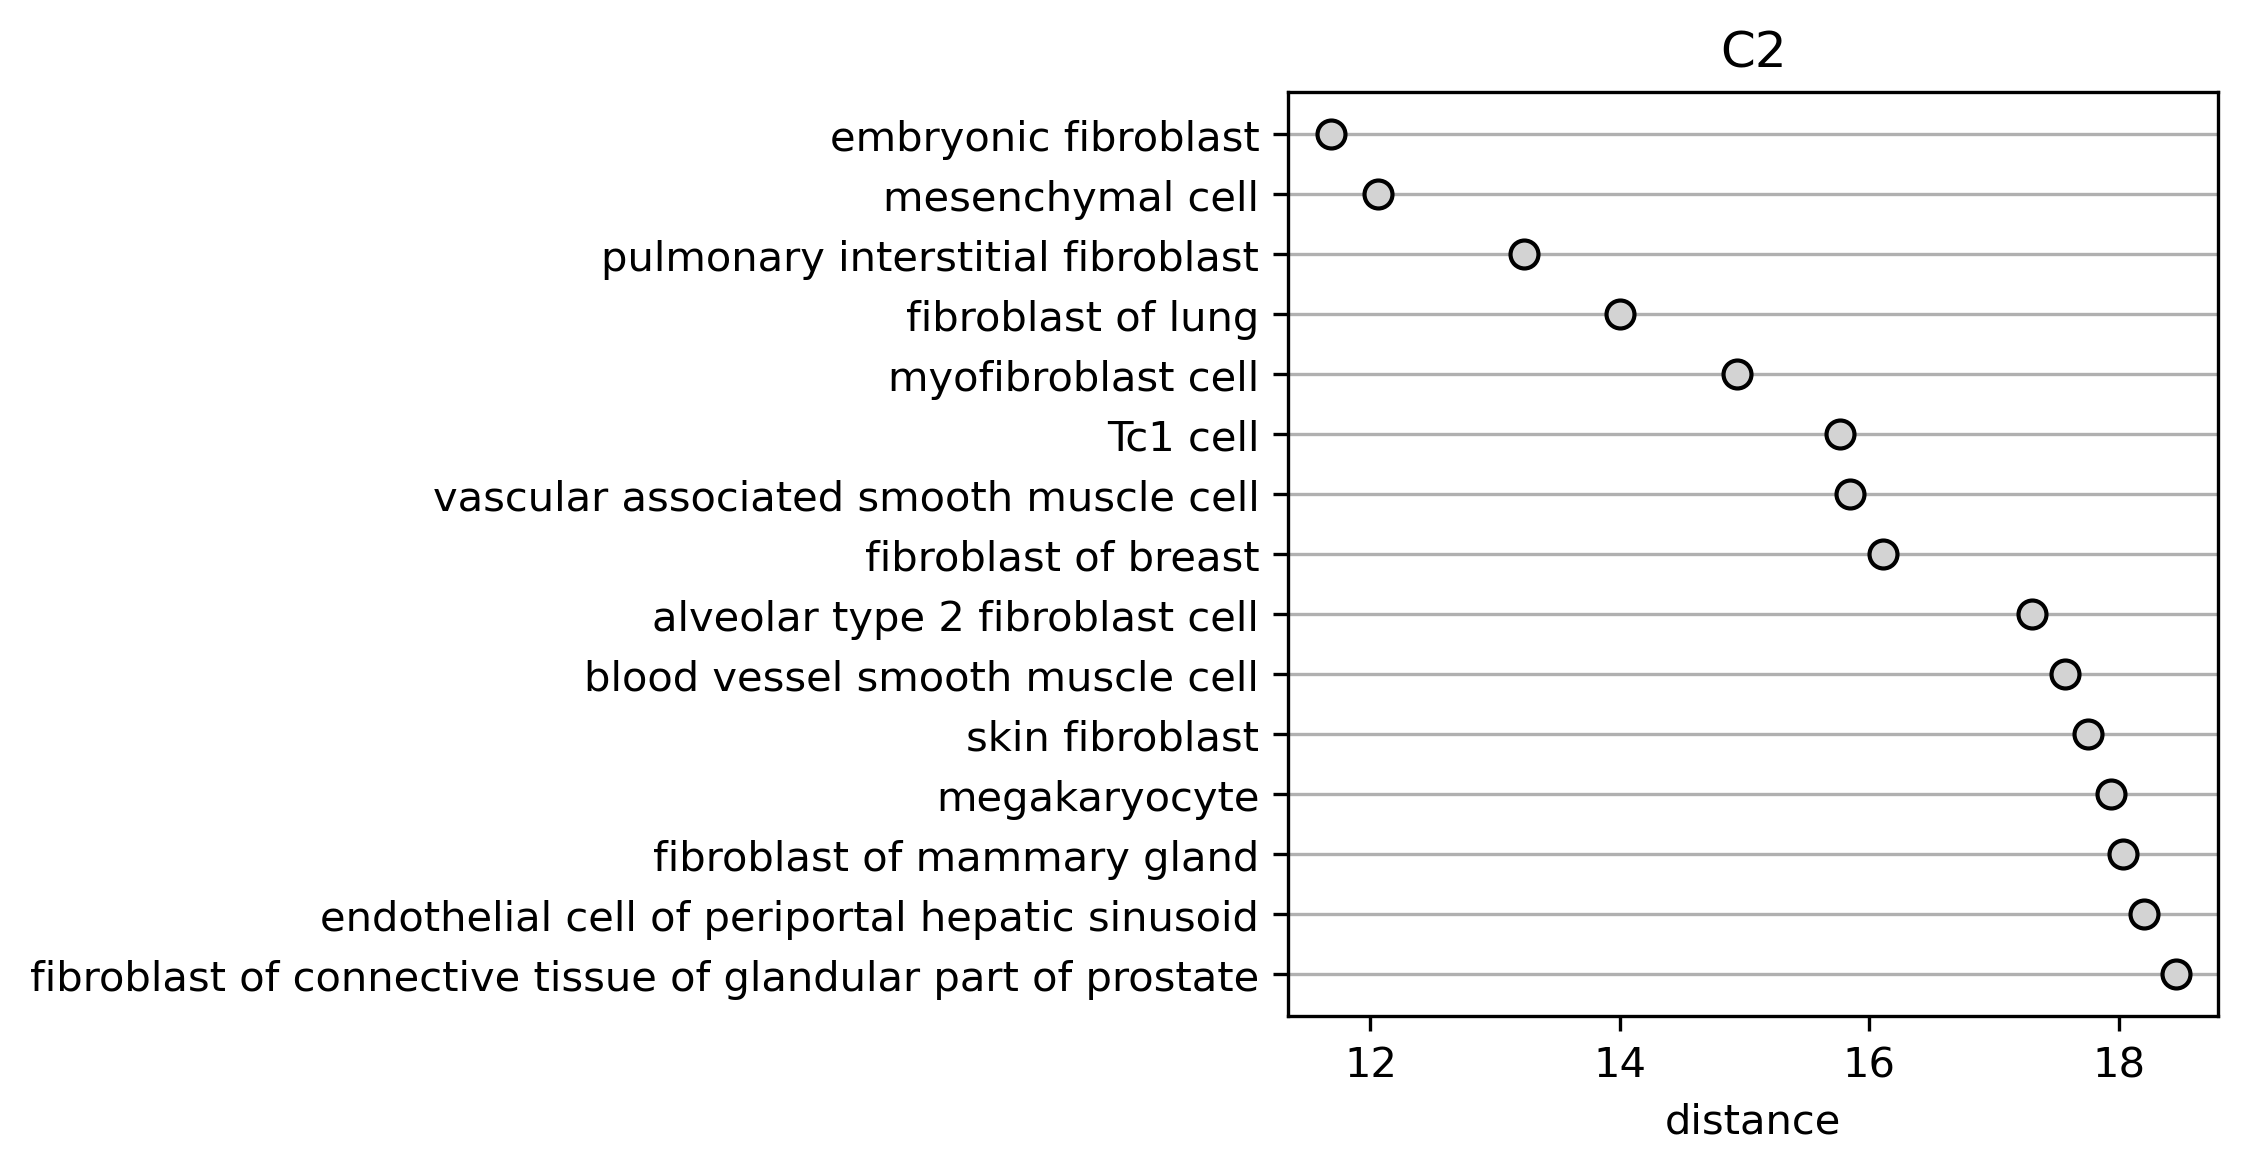

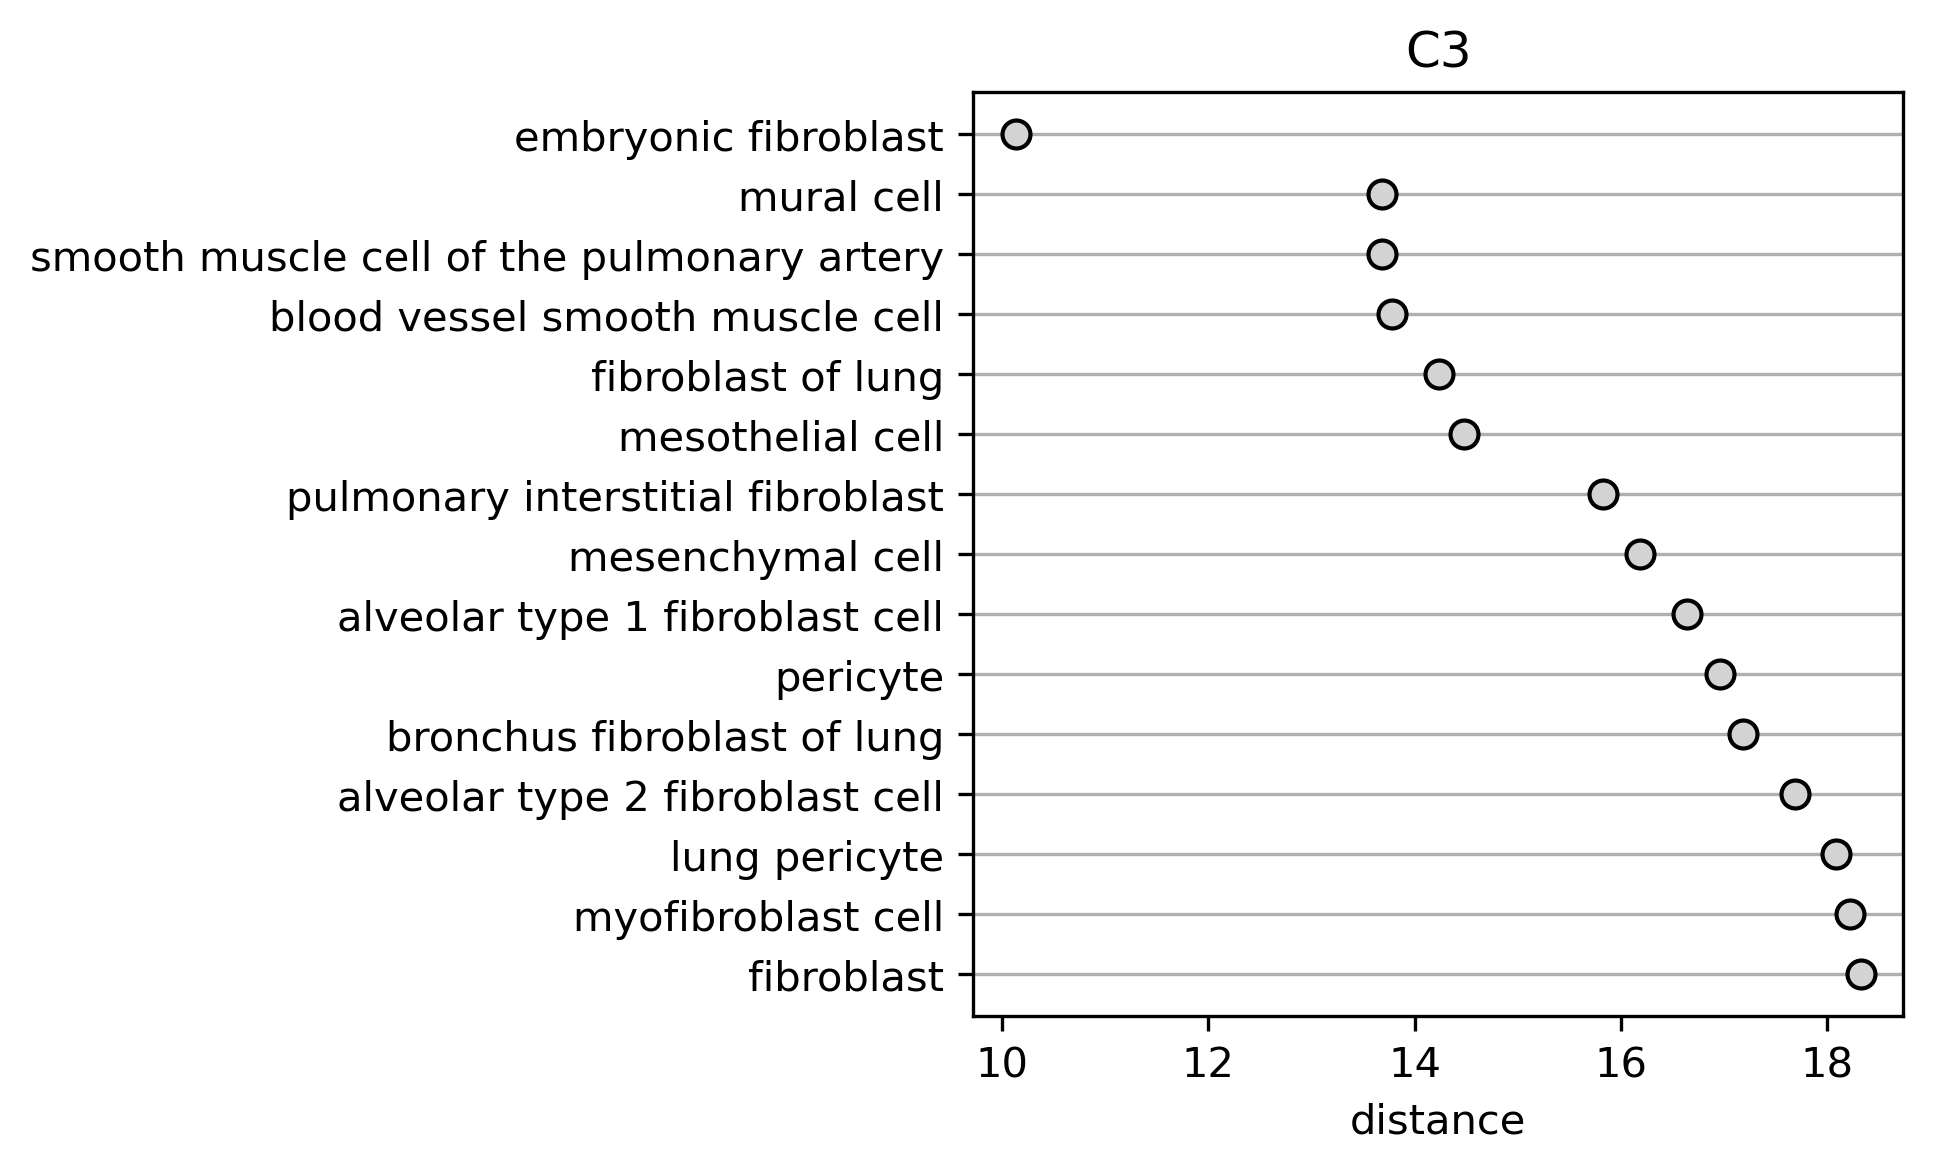

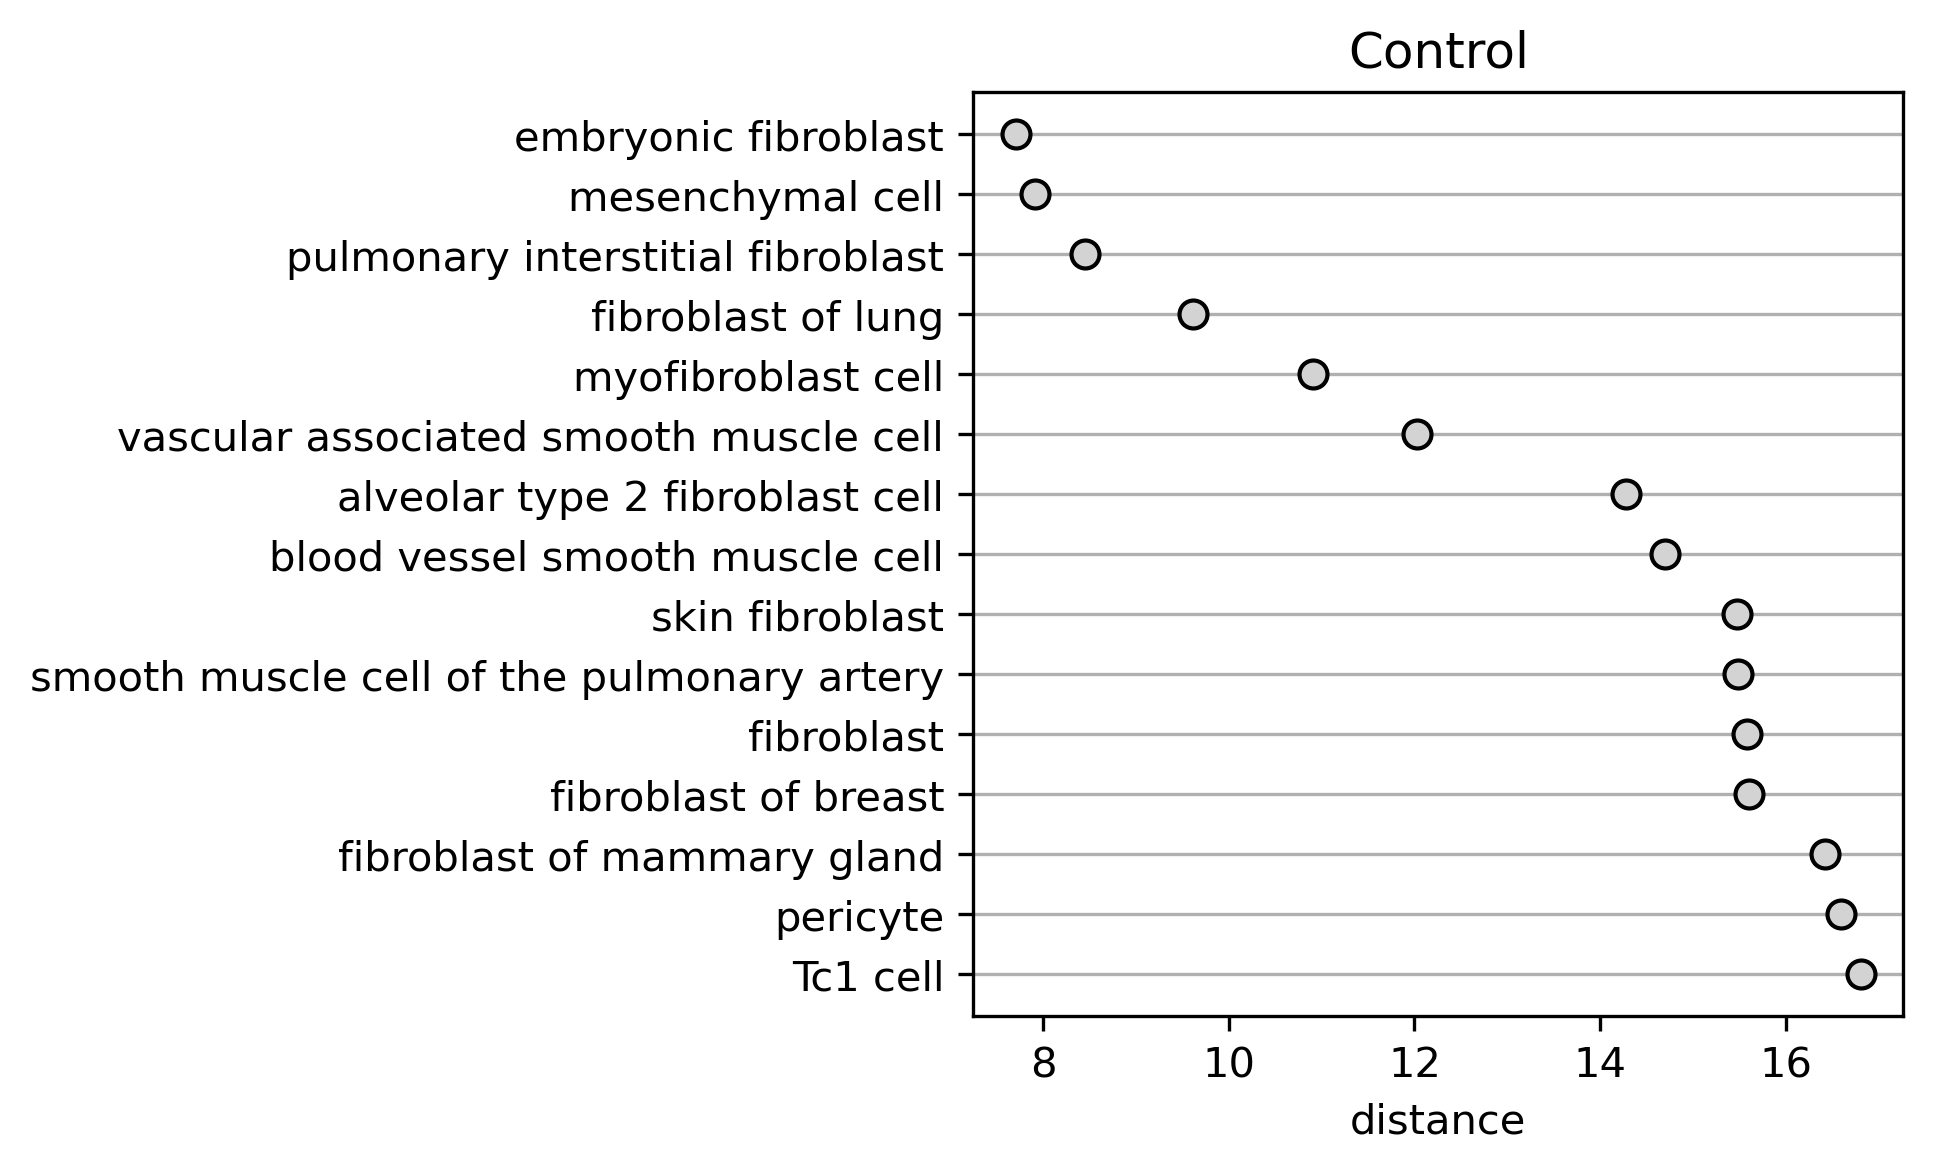

In [23]:
# Step 1: Make a copy

X = adata.obsm['X_pca'][:, 0:7]
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists, 
    index=pd.MultiIndex.from_frame(adata.obs),
    columns=pd.MultiIndex.from_frame(adata.obs),
)
print(f"{df.shape=}")

pdf = df.copy()

level = 'cell_type'

pdf.index = pdf.columns.get_level_values(level)
pdf.columns = pdf.columns.get_level_values(level)
print(f"{pdf.shape=}")

top = 15
focus = ['C2', 'C3', 'Control']

for cell_type in focus:

    vec = pdf[cell_type].sort_values().drop(index=focus)
    vec.name = 'distance'
    vec = vec.reset_index(drop=False)
    vec['cell_type'] = vec['cell_type'].astype(str)

    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['figure.figsize'] = 4, top / 3.75
    sns.scatterplot(
        data=vec.head(top),
        x='distance',
        y='cell_type',
        ec='k',
        color='lightgrey',
        lw=1,
        zorder=10,
        s=45,
        legend=False,
    )

    plt.grid(axis='y')
    plt.ylabel("")
    plt.title(cell_type)

    # ax = plt.gca()
    # labels = [textwrap.fill(label.get_text(), width=35) for label in ax.get_yticklabels()]
    # ax.set_yticklabels(labels, fontsize=9)
    plt.show()    
    # break


# Write output file

In [24]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudobulk/atlas.h5ad"
adata.write(outpath)
adata

CPU times: user 98.5 ms, sys: 108 ms, total: 206 ms
Wall time: 616 ms


AnnData object with n_obs × n_vars = 191 × 16390
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4'
    var: 'n_counts', 'n_cells', 'filter_pass'
    uns: 'pca', 'neighbors', 'paga', 'level2_sizes', 'level2_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'sum', 'log_norm', 'probs'
    obsp: 'distances', 'connectivities'

# Archive

In [25]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# Step 1: Make a copy
pdf = df.copy()

row_levels = ['cell_type', 'level2']
col_level = 'level1'

new_index = pd.MultiIndex.from_arrays(
    [pdf.index.get_level_values(lvl) for lvl in row_levels],
    names=[f"{x}_col" for x in row_levels],
)
pdf.index = new_index
pdf.columns = pdf.columns.get_level_values(col_level)


pdf = pdf.reset_index(drop=False)
pdf = pd.melt(pdf, id_vars=[f"{x}_col" for x in row_levels])

pdf = pdf[pdf['level1'].isin(['C2', 'C3', 'Control'])] 
pdf = pdf[~pdf['level2_col'].isin(['C2', 'C3', 'Control', 'Hematopoietic Cell'])] 

pdf['level2_col'] = pdf['level2_col'].astype(str)
pdf['level1'] = pdf['level1'].astype(str)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 3.5

sns.boxplot(
    pdf,
    x='level1',
    hue='level2_col',
    y='value',
    palette=color_dict,
    showfliers=False,
    linecolor='k',
    capprops={'lw' : 0},
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='center right',
    bbox_to_anchor=(1.55, 0.5),
    frameon=False,
)

plt.ylabel('distance')
plt.xlabel('')

sns.despine()

In [ ]:
# Restrict to desired level1 values (already in your code)
wanted = ['C2', 'C3', 'Control']
pdf = pdf[pdf['level1'].isin(wanted)] 
pdf = pdf[~pdf['level2_col'].isin(['C2', 'C3', 'Control', 'Hematopoietic Cell'])] 

# Set category order for consistent faceting
pdf['level1'] = pd.Categorical(pdf['level1'], categories=wanted, ordered=True)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (5, 7)  # taller for 3 rows

g = sns.FacetGrid(
    pdf, 
    row='level1',
    sharex=True, 
    sharey=True,
    aspect=1,
    height=2.5,
)

g.map_dataframe(
    sns.boxplot,
    x='level2_col',
    y='value',
    palette=color_dict,
    showfliers=False,
    linecolor='k',
    capprops={'lw': 0},
)

g.set_axis_labels('', 'distance')

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

# After creating g = sns.FacetGrid(...)
for ax, label in zip(g.axes.flat, g.row_names):
    ax.set_title(label)

g.figure.tight_layout()
sns.despine()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure order for clarity
wanted = ['C2', 'C3', 'Control']
pdf = pdf[pdf['level1'].isin(wanted)]
pdf = pdf[~pdf['level2_col'].isin(['C2', 'C3', 'Control', 'Hematopoietic Cell'])]

pdf['level1'] = pd.Categorical(pdf['level1'], categories=wanted, ordered=True)

# Choose which level2_col values to show (optional: adjust as needed)
unique_level2 = pdf['level2_col'].unique()
unique_level2 = sorted(unique_level2)  # Sort for consistent facet order

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (8, 5)  # Adjust as needed

g = sns.FacetGrid(
    pdf,
    col='level2_col',
    col_wrap=2,  # two columns of subplots
    sharey=True,
    sharex=True,
    height=3,
    aspect=0.75,
)

g.map_dataframe(
    sns.boxplot,
    x='level1',
    y='value',
    palette=['C1','C2', 'lightgrey'],
    showfliers=False,
    linecolor='k',
    width=0.5,
    capprops={'lw': 0},
)

g.set_axis_labels('level1', 'distance')

# Set facet titles to just the value, not "level2_col = value"
for ax, label in zip(g.axes.flat, g.col_names):
    ax.set_title(label)

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(0)

g.figure.tight_layout()
sns.despine()
plt.show()


In [ ]:
break

In [ ]:
# Step 1: Make a copy
pdf = df.copy()

row_levels = ['cell_type', 'level2']
col_level = 'level1'

new_index = pd.MultiIndex.from_arrays(
    [pdf.index.get_level_values(lvl) for lvl in row_levels],
    names=[f"{x}_col" for x in row_levels],
)
pdf.index = new_index
pdf.columns = pdf.columns.get_level_values(col_level)


pdf = pdf.reset_index(drop=False)
pdf = pd.melt(pdf, id_vars=[f"{x}_col" for x in row_levels])

pdf = pdf[pdf['level1'].isin(['C2', 'C3', 'Control'])] 
pdf = pdf[~pdf['level2_col'].isin(['C2', 'C3', 'Control', 'Hematopoietic Cell'])] 

pdf['level2_col'] = pdf['level2_col'].astype(str)
pdf['level1'] = pdf['level1'].astype(str)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 3.5

sns.boxplot(
    pdf,
    x='level2_col',
    hue='level1',
    y='value',
    palette=['C1','C2', 'lightgrey'],
    showfliers=False,
    linecolor='k',
    capprops={'lw' : 0},
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='center right',
    bbox_to_anchor=(1.55, 0.5),
    frameon=False,
)

plt.ylabel('distance')
plt.xlabel('')
plt.xticks(rotation=90)

sns.despine()

In [ ]:
pdf.head()

In [ ]:
break

In [ ]:
break

In [ ]:
# break